In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
df = pd.read_csv(r'C:/Users/Vido/Desktop/EPL448/accepted_2007_to_2018q4.csv/accepted_2007_to_2018q4.csv', low_memory=False)

In [132]:
feauture_data = [
"hardship_flag","hardship_type","hardship_reason","hardship_status","deferral_term",
"hardship_amount","hardship_start_date","hardship_end_date","payment_plan_start_date",
"hardship_length","hardship_dpd","hardship_loan_status",
"orig_projected_additional_accrued_interest","hardship_payoff_balance_amount",
"hardship_last_payment_amount","disbursement_method","debt_settlement_flag",
"debt_settlement_flag_date","settlement_status","settlement_date",
"settlement_amount","settlement_percentage","settlement_term",
"collection_recovery_fee","last_pymnt_amnt","last_pymnt_d","next_pymnt_d",
"out_prncp","out_prncp_inv","policy_code","recoveries","total_pymnt",
"total_pymnt_inv","total_rec_int","total_rec_late_fee","total_rec_prncp",
"pymnt_plan"
]
#removing future data, not available at the occurance of the debt
df_all_but_future = df.drop(columns=feauture_data) # drop feature data from dataset

df_all_but_future.head(100)

joint_laon_data=[
"dti_joint", "annual_inc_joint", "verification_status_joint", "revol_bal_joint", "sec_app_fico_range_low",
"sec_app_fico_range_high", "sec_app_earliest_cr_line", "sec_app_inq_last_6mths", "sec_app_mort_acc", 
"sec_app_open_acc","sec_app_revol_util", "sec_app_open_act_il","sec_app_num_rev_accts","sec_app_chargeoff_within_12_mths", 
"sec_app_collections_12_mths_ex_med", "sec_app_mths_since_last_major_derog",
]

df_all_but_future_joint = df_all_but_future.drop(columns=joint_laon_data)

obselete_features = [
    #"id",
    "initial_list_status",
    "member_id",
    "bc_open_to_buy",#inverse of bc_util
    "last_credit_pull_d",#last time credit was checking by LendingClub
    "desc",
    "funded_amnt_inv",
    "title",
    "url",
    "zip_code",
    "funded_amnt"

]

Proxy_variables=[
    "fico_range_high",
    "fico_range_low",
    "grade",
    "sub_grade",
    "installment",
    #"int_rate",
]

df_ex_future_joint_obs_proxy=df_all_but_future_joint.drop(columns=(obselete_features + Proxy_variables))



print(df_ex_future_joint_obs_proxy.shape)

print(df_ex_future_joint_obs_proxy.columns)


exist = [
"addr_state","annual_inc","annual_inc_joint","application_type","dti","dti_joint",
"emp_length","emp_title","funded_amnt","funded_amnt_inv","grade","home_ownership",
"id","initial_list_status","installment","int_rate","issue_d","loan_amnt",
"laon-status","member_id","purpose","pymnt_plan","sub_grade","term","title","url",
"verification_status","zip_code","acc_now_delinq","acc_open_past_24mths","all_util",
"avg_cur_bal","bc_open_to_buy","bc_util","chargeoff_within_12_mths",
"collections_12_mths_ex_med","delinq_2yrs","delinq_amnt","earliest_cr_line",
"fico_range_high","fico_range_low","il_util","inq_fi","inq_last_6mths",
"inq_last_12m","mths_since_recent_inq","last_credit_pull_d","max_bal_bc",
"mo_sin_old_il_acct","mo_sin_old_rev_tl_op","mo_sin_rcnt_rev_tl_op",
"mths_since_rcnt_il","mo_sin_rcnt_tl","mort_acc","mths_since_last_delinq",
"mths_since_last_major_derog","mths_since_last_record","mths_since_recent_bc_dlq",
"mths_since_recent_revol_delinq","num_accts_ever_120_pd","num_actv_bc_tl",
"num_actv_rev_tl","num_bc_sats","num_bc_tl","num_il_tl","num_op_rev_tl",
"num_rev_accts","num_rev_tl_bal_gt_0","num_sats","num_tl_120dpd_2m",
"num_tl_30dpd","num_tl_90g_dpd_24m","num_tl_op_past_12m","open_acc","open_acc_6m",
"open_act_il","open_il_12m","open_il_24m","open_rv_12m","open_rv_24m",
"pct_tl_nvr_dlq","percent_bc_gt_75","pub_rec","pub_rec_bankruptcies","revol_bal",
"revol_util","tax_liens","tot_coll_amt","tot_cur_bal","tot_hi_cred_lim","total_acc",
"total_bal_ex_mort","total_bal_il","total_bc_limit","total_cu_tl",
"total_il_high_credit_limit","total_rev_hi_lim","collection_recovery_fee",
"last_pymnt_amnt","last_pymnt_d","next_pymnt_d","out_prncp","out_prncp_inv",
"policy_code","recoveries","total_pymnt","total_pymnt_inv","total_rec_int",
"total_rec_late_fee","total_rec_prncp","mths_since_recent_bc"
]


remaining_columns = [c for c in df_ex_future_joint_obs_proxy.columns if c not in exist]

# print them
for col in remaining_columns:
    print(col)

    


#for i, text in enumerate(df['desc'].dropna().head(100), 1): # checking some none nan desc to understand if they are usefull. they are not
#    print(f"Row {i}:")
#    print(text)
#    print("\n" + "-"*80 + "\n")

(2260701, 83)
Index(['id', 'loan_amnt', 'term', 'int_rate', 'emp_title', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'last_fico_range_high',
       'last_fico_range_low', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'application_type', 'acc_now_delinq',
       'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il',
       'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il',
       'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_util',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_

['Individual' 'Joint App' nan]
['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)' 'Default' nan
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']
(2139958, 83)
          id  loan_amnt        term  int_rate  \
0   68407277     3600.0   36 months     13.99   
1   68355089    24700.0   36 months     11.99   
3   66310712    35000.0   60 months     14.85   
4   68476807    10400.0   60 months     22.45   
5   68426831    11950.0   36 months     13.44   
6   68476668    20000.0   36 months      9.17   
7   67275481    20000.0   36 months      8.49   
8   68466926    10000.0   36 months      6.49   
9   68616873     8000.0   36 months     11.48   
10  68356421    22400.0   60 months     12.88   

                                  emp_title emp_length home_ownership  \
0                                   leadman  10+ years       MORTGAGE   
1                                  Engineer  10

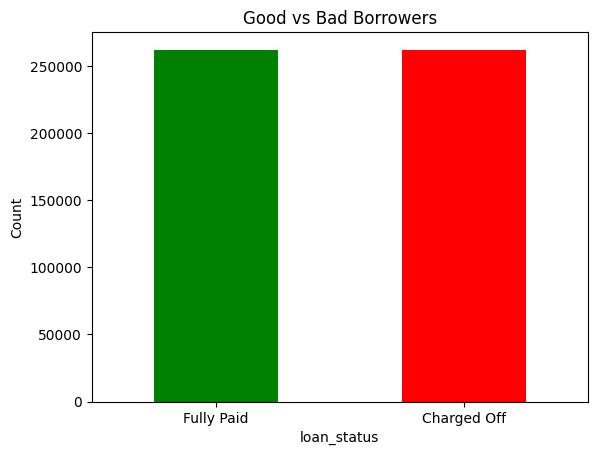

In [133]:
#randomly selective equal amount of fully paid and charged off datas and not getting the joint datas
#df_ex_future_joint_obs_proxy = df_ex_future_joint_obs_proxy()
print(df_ex_future_joint_obs_proxy['application_type'].unique()) # checking application type levels, confirmed its two level
print(df_ex_future_joint_obs_proxy['loan_status'].unique())
#removing all the joint rows filtering by application_type
df_individual_ex_future_joint_obs_proxy = df_ex_future_joint_obs_proxy[df_ex_future_joint_obs_proxy['application_type'] == 'Individual'] #filtering individual applicants only

print(df_individual_ex_future_joint_obs_proxy.shape) #Still a lot of data left
print(df_individual_ex_future_joint_obs_proxy.head(10)) # confirming individual only


#now we have to create a function that get equal amount of charged off and fully payed loans ! we ignore current loan statuses such as current grace period 30 days as we want our target to describe only loans whose final outcome is known
loan_counts = df_individual_ex_future_joint_obs_proxy['loan_status'].value_counts()

print(loan_counts)

temp=df_individual_ex_future_joint_obs_proxy[df_individual_ex_future_joint_obs_proxy['loan_status'].isin(['Fully Paid','Charged Off'])].copy()

temp.head(10) # confirming eveerything is individual and Fully paid charge off only

#balancing data
#seperating Charged off and fully paid ones
charged_off = temp[temp['loan_status'] == 'Charged Off']
fully_paid = temp[temp['loan_status'] == 'Fully Paid']
    
fully_paid_downsampling = fully_paid.sample(262215, random_state=42) # getting 262215 fully paid loans randomly
    
# creating new dataset that represents both cases of target variable 
balanced_df = pd.concat([charged_off, fully_paid_downsampling])
    
# reshufling to avoid charged off going going all to test or train data
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Confirm balanced data     
loan_counts = balanced_df['loan_status'].value_counts()

print(loan_counts)

balanced_df

import matplotlib.pyplot as plt

balanced_df['loan_status'].value_counts()[['Fully Paid', 'Charged Off']].plot(kind='bar', color=['green', 'red'])
plt.title('Good vs Bad Borrowers')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [134]:
#split and encode missing
#splitting data to test and train datasets
balanced_df=balanced_df.drop(columns=["application_type"]) #is no longer needed as it was used already to filter out the joint applications. 

X = balanced_df.drop(columns=["loan_status"])
Y = balanced_df['loan_status']



from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.80, random_state=1)

X_train = X_train.copy()
X_test = X_test.copy()

X_train





,id,loan_amnt,term,int_rate,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
392193,38598337,20000.0,60 months,14.99,technician,6 years,MORTGAGE,80000.0,Source Verified,Jan-2015,debt_consolidation,LA,25.16,4.0,May-1988,0.0,16.0,NaN,5.0,0.0,7241.0,69.0,20.0,584.0,580.0,0.0,NaN,0.0,0.0,61461.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10500.0,NaN,NaN,NaN,2.0,15365.0,NaN,0.0,0.0,87.0,320.0,8.0,8.0,1.0,76.0,16.0,1.0,16.0,0.0,0.0,1.0,1.0,9.0,5.0,3.0,14.0,1.0,5.0,0.0,0.0,0.0,1.0,80.0,NaN,0.0,0.0,82630.0,61461.0,0.0,72130.0
199618,65109298,5400.0,36 months,16.55,Counselor,3 years,RENT,45000.0,Verified,Nov-2015,debt_consolidation,CA,13.87,0.0,Jul-2012,1.0,NaN,NaN,8.0,0.0,5463.0,51.5,8.0,539.0,535.0,0.0,NaN,0.0,0.0,15557.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10600.0,NaN,NaN,NaN,6.0,1945.0,77.2,0.0,0.0,21.0,40.0,7.0,7.0,0.0,7.0,NaN,5.0,NaN,0.0,2.0,4.0,2.0,2.0,1.0,7.0,7.0,5.0,8.0,0.0,0.0,0.0,5.0,100.0,50.0,0.0,0.0,25263.0,15557.0,5800.0,14663.0
440877,42733391,12950.0,36 months,12.69,Commerical billing specailist,10+ years,RENT,44000.0,Source Verified,Mar-2015,debt_consolidation,CA,10.47,0.0,Jan-1987,0.0,NaN,60.0,20.0,1.0,8814.0,40.2,64.0,604.0,600.0,0.0,NaN,0.0,0.0,8814.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21900.0,NaN,NaN,NaN,12.0,518.0,57.1,0.0,0.0,145.0,338.0,12.0,6.0,5.0,12.0,NaN,8.0,NaN,0.0,6.0,11.0,8.0,22.0,11.0,20.0,48.0,11.0,18.0,0.0,0.0,0.0,3.0,100.0,57.1,1.0,0.0,21900.0,8814.0,10700.0,0.0
449111,46611319,14900.0,36 months,16.99,Driver,10+ years,RENT,34000.0,Verified,Apr-2015,debt_consolidation,TX,17.72,0.0,Nov-2000,0.0,NaN,NaN,7.0,0.0,10091.0,39.1,10.0,519.0,515.0,0.0,NaN,0.0,0.0,17899.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25800.0,NaN,NaN,NaN,4.0,2557.0,47.7,0.0,0.0,44.0,173.0,11.0,5.0,0.0,11.0,NaN,NaN,NaN,0.0,4.0,5.0,5.0,7.0,2.0,6.0,8.0,5.0,7.0,0.0,0.0,0.0,2.0,100.0,0.0,0.0,0.0,33800.0,17899.0,21000.0,8000.0
391434,69613130,12000.0,36 months,15.77,Project Manager,10+ years,MORTGAGE,110000.0,Source Verified,Jan-2016,debt_consolidation,NY,16.03,6.0,Jul-1984,1.0,1.0,NaN,14.0,0.0,32528.0,84.5,31.0,599.0,595.0,0.0,13.0,1.0,0.0,152113.0,3.0,2.0,2.0,2.0,5.0,22538.0,86.0,2.0,4.0,1951.0,85.0,38500.0,0.0,0.0,1.0,6.0,11701.0,99.2,0.0,0.0,123.0,378.0,3.0,3.0,5.0,14.0,1.0,3.0,1.0,0.0,3.0,9.0,3.0,7.0,6.0,11.0,20.0,9.0,14.0,0.0,1.0,2.0,4.0,64.5,100.0,0.0,0.0,219180.0,55066.0,3800.0,26330.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371403,58281191,24000.0,60 months,10.99,Data Aide,4 years,RENT,65000.0,Source Verified,Aug-2015,credit_card,CA,15.65,1.0,Jun-2003,0.0,14.0,NaN,18.0,0.0,30582.0,33.8,44.0,534.0,530.0,1.0,14.0,0.0,0.0,41275.0,NaN,Na

In [135]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
#print(X_train.dtypes)
#X_train.head(6)

#Editing objects of type X year or X month into float
X_train['term'] = pd.to_numeric(X_train['term'].astype(str).str.extract(r'(\d+)')[0]).astype("Int64")
            #print(X_train['term'])
X_test['term'] = pd.to_numeric(X_test['term'].astype(str).str.extract(r'(\d+)')[0]).astype("Int64")
            #print(X_train['term'])

X_train['emp_length'] = pd.to_numeric(X_train['emp_length'].astype(str).str.extract(r'(\d+)')[0]).astype("Int64")
            #print(X_train['emp_length'])
X_test['emp_length'] = pd.to_numeric(X_test['emp_length'].astype(str).str.extract(r'(\d+)')[0]).astype("Int64")
            #print(X_train['emp_length'])

            
#Encoding home_ownership and verification status            
#print(X_train['home_ownership'].value_counts())
#print(X_train['verification_status'].value_counts())



# Keep only the main categories
X_train = X_train[X_train['home_ownership'].isin(['MORTGAGE', 'RENT', 'OWN'])].copy()
X_test = X_test[X_test['home_ownership'].isin(['MORTGAGE', 'RENT', 'OWN'])].copy()


        #print(X_train['home_ownership'].value_counts())
        #print(X_train['verification_status'].value_counts())


        #X_train = pd.get_dummies(X_train, columns=['home_ownership', 'verification_status'])
home_map = {'RENT': 1, 'MORTGAGE': 2, 'OWN': 3} #rent more risky own less risky
verif_map = {'Not Verified': 1, 'Verified': 2, 'Source Verified': 3} # not verified more risky verified source less risky

# Edit values to 1,2,3 according to map
X_train['home_ownership'] = X_train['home_ownership'].map(home_map).astype(int)
X_train['verification_status'] = X_train['verification_status'].map(verif_map).astype(int)

X_test['home_ownership'] = X_test['home_ownership'].map(home_map).astype(int)
X_test['verification_status'] = X_test['verification_status'].map(verif_map).astype(int)

#checking other object levels


print(X_train.dtypes)
X_train

#Dropping target var left in case
X_train=X_train.drop(['last_fico_range_high','last_fico_range_low'], axis=1)
X_test=X_test.drop(['last_fico_range_high','last_fico_range_low'], axis=1)


id                                 object
loan_amnt                         float64
term                                Int64
int_rate                          float64
emp_title                          object
emp_length                          Int64
home_ownership                      int64
annual_inc                        float64
verification_status                 int64
issue_d                            object
purpose                            object
addr_state                         object
dti                               float64
delinq_2yrs                       float64
earliest_cr_line                   object
inq_last_6mths                    float64
mths_since_last_delinq            float64
mths_since_last_record            float64
open_acc                          float64
pub_rec                           float64
revol_bal                         float64
revol_util                        float64
total_acc                         float64
last_fico_range_high              

In [136]:
# Analyze emp_length before any filling and save the exact rows we would affect
print("X_train emp_length missing:", X_train["emp_length"].isna().sum())
print("X_test emp_length missing:", X_test["emp_length"].isna().sum())

print("\nX_train emp_length summary:")
print(X_train["emp_length"].describe())

print("\nX_train emp_length value counts:")
print(X_train["emp_length"].value_counts(dropna=False).sort_index())

emp_length_train_missing_rows = X_train[X_train["emp_length"].isna()].copy()
emp_length_train_known_rows = X_train[X_train["emp_length"].notna()].copy()
emp_length_test_missing_rows = X_test[X_test["emp_length"].isna()].copy()
emp_length_test_known_rows = X_test[X_test["emp_length"].notna()].copy()

emp_length_analysis_store = {
    'train_missing': emp_length_train_missing_rows,
    'train_known': emp_length_train_known_rows,
    'test_missing': emp_length_test_missing_rows,
    'test_known': emp_length_test_known_rows,
}

print("\nStored analysis tables:")
print("train_missing", emp_length_analysis_store['train_missing'].shape)
print("train_known", emp_length_analysis_store['train_known'].shape)
print("test_missing", emp_length_analysis_store['test_missing'].shape)
print("test_known", emp_length_analysis_store['test_known'].shape)

emp_length_preview_cols = [col for col in ["id", "loan_amnt", "term", "int_rate", "annual_inc", "home_ownership", "verification_status", "purpose", "emp_length"] if col in X_train.columns]
print("\nPreview of train rows with missing emp_length:")
print(emp_length_train_missing_rows[emp_length_preview_cols].head())

print("\nPreview of train rows with known emp_length:")
print(emp_length_train_known_rows[emp_length_preview_cols].head())


X_train emp_length missing: 26830
X_test emp_length missing: 6674

X_train emp_length summary:
count    392569.0
mean     6.027047
std      3.558593
min           1.0
25%           2.0
50%           6.0
75%          10.0
max          10.0
Name: emp_length, dtype: Float64

X_train emp_length value counts:
emp_length
1        61104
2        38141
3        33728
4        25030
5        26107
6        19419
7        18658
8        19065
9        16003
10      135314
<NA>     26830
Name: count, dtype: Int64

Stored analysis tables:
train_missing (26830, 79)
train_known (392569, 79)
test_missing (6674, 79)
test_known (98176, 79)

Preview of train rows with missing emp_length:
               id  loan_amnt  term  int_rate  annual_inc  home_ownership  \
434089  116475595    16550.0    36     11.99     36000.0               1   
503294    7049895     3000.0    36      7.62     21000.0               1   
85923    46706228     5000.0    36     12.29     78000.0               2   
343462   56020713

In [137]:
# Fill emp_length using clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

n_clusters = 4
cluster_features = ['loan_amnt', 'dti', 'annual_inc', 'open_acc', 'total_acc', 'revol_bal', 'revol_util_num']

def prepare_emp_length_cluster_frame(frame):
    prepared = frame.copy()
    prepared['revol_util_num'] = pd.to_numeric(
        prepared['revol_util'].astype(str).str.replace('%', '', regex=False),
        errors='coerce'
    )
    prepared['filled_emp_length'] = prepared['emp_length'].astype('Int64')
    prepared['emp_cluster'] = pd.Series(pd.NA, index=prepared.index, dtype='Int64')
    prepared['emp_length_cluster_estimate'] = pd.Series(pd.NA, index=prepared.index, dtype='Int64')
    prepared['emp_length_fill_source'] = 'original'
    return prepared

X_train_emp_cluster = prepare_emp_length_cluster_frame(X_train)
X_test_emp_cluster = prepare_emp_length_cluster_frame(X_test)

known_train = X_train_emp_cluster[X_train_emp_cluster['emp_length'].notna()].copy()
known_train = known_train.dropna(subset=cluster_features)
known_train['emp_length_num'] = known_train['emp_length'].astype(int)

print('Known training rows used for clustering:', known_train.shape[0])

X_known = known_train[cluster_features].copy()
scaler = StandardScaler()
X_known_scaled = scaler.fit_transform(X_known)

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
known_train['emp_cluster'] = kmeans.fit_predict(X_known_scaled)
X_train_emp_cluster.loc[known_train.index, 'emp_cluster'] = known_train['emp_cluster'].astype('Int64')

cluster_summary = known_train.groupby('emp_cluster')['emp_length_num'].agg(
    median='median',
    mean='mean',
    mode=lambda s: int(s.mode().iat[0]),
    count='count'
).sort_index()
cluster_summary['cluster_to_year'] = cluster_summary['median'].round().astype(int)
cluster_to_year = cluster_summary['cluster_to_year'].to_dict()

print('Cluster emp_length summary (known train rows):')
print(cluster_summary)
print('Cluster to representative emp_length years:')
print(cluster_to_year)

def assign_emp_length_clusters(prepared_frame, frame_name):
    unknown_rows = prepared_frame[prepared_frame['emp_length'].isna()].copy()
    unknown_rows = unknown_rows.dropna(subset=cluster_features)

    if unknown_rows.empty:
        print(f'No missing {frame_name} rows with complete clustering features to fill.')
        return prepared_frame

    X_unknown = unknown_rows[cluster_features].copy()
    X_unknown_scaled = scaler.transform(X_unknown)
    distances = np.linalg.norm(X_unknown_scaled[:, None, :] - kmeans.cluster_centers_[None, :, :], axis=2)
    unknown_rows['emp_cluster'] = np.argmin(distances, axis=1)
    unknown_rows['emp_length_cluster_estimate'] = unknown_rows['emp_cluster'].map(cluster_to_year).astype('Int64')
    unknown_rows['filled_emp_length'] = unknown_rows['emp_length_cluster_estimate']
    unknown_rows['emp_length_fill_source'] = 'cluster_median'

    prepared_frame.loc[unknown_rows.index, 'emp_cluster'] = unknown_rows['emp_cluster'].astype('Int64')
    prepared_frame.loc[unknown_rows.index, 'emp_length_cluster_estimate'] = unknown_rows['emp_length_cluster_estimate']
    prepared_frame.loc[unknown_rows.index, 'filled_emp_length'] = unknown_rows['filled_emp_length']
    prepared_frame.loc[unknown_rows.index, 'emp_length_fill_source'] = unknown_rows['emp_length_fill_source']

    print(f'{frame_name} rows filled from cluster median:', unknown_rows.shape[0])
    return prepared_frame

X_train_emp_cluster = assign_emp_length_clusters(X_train_emp_cluster, 'X_train')
X_test_emp_cluster = assign_emp_length_clusters(X_test_emp_cluster, 'X_test')

train_fill_export = X_train_emp_cluster[['id', 'emp_length', 'filled_emp_length', 'emp_cluster', 'emp_length_cluster_estimate', 'emp_length_fill_source']].copy()
test_fill_export = X_test_emp_cluster[['id', 'emp_length', 'filled_emp_length', 'emp_cluster', 'emp_length_cluster_estimate', 'emp_length_fill_source']].copy()
combined_fill_export = pd.concat([train_fill_export, test_fill_export], axis=0, ignore_index=True)

emp_length_fill_store = {
    'train_fill_export': train_fill_export,
    'test_fill_export': test_fill_export,
    'id_only_fill_export': combined_fill_export[['id', 'filled_emp_length']].copy(),
}

print('\nStored fill tables:')
print('train_fill_export', emp_length_fill_store['train_fill_export'].shape)
print('test_fill_export', emp_length_fill_store['test_fill_export'].shape)
print('id_only_fill_export', emp_length_fill_store['id_only_fill_export'].shape)


Known training rows used for clustering: 392341
Cluster emp_length summary (known train rows):
             median      mean  mode   count  cluster_to_year
emp_cluster                                                 
0               6.0  5.921215    10  130482                6
1               7.0  6.269795    10   83834                7
2               5.0  5.669872    10  115955                5
3               8.0  6.590414    10   62070                8
Cluster to representative emp_length years:
{0: 6, 1: 7, 2: 5, 3: 8}
X_train rows filled from cluster median: 26818
X_test rows filled from cluster median: 6671

Stored fill tables:
train_fill_export (419399, 6)
test_fill_export (104850, 6)
id_only_fill_export (524249, 2)


Elbow summary:
    k  avg_distance_to_centroid
0   1                  2.300920
1   2                  2.044304
2   3                  1.920199
3   4                  1.798857
4   5                  1.765142
5   6                  1.759993
6   7                  1.680562
7   8                  1.630739
8   9                  1.591598
9  10                  1.558536
Elbow sample size: 50000


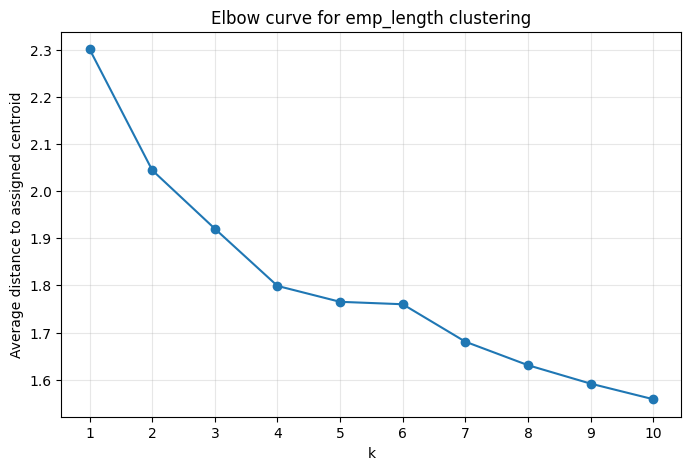

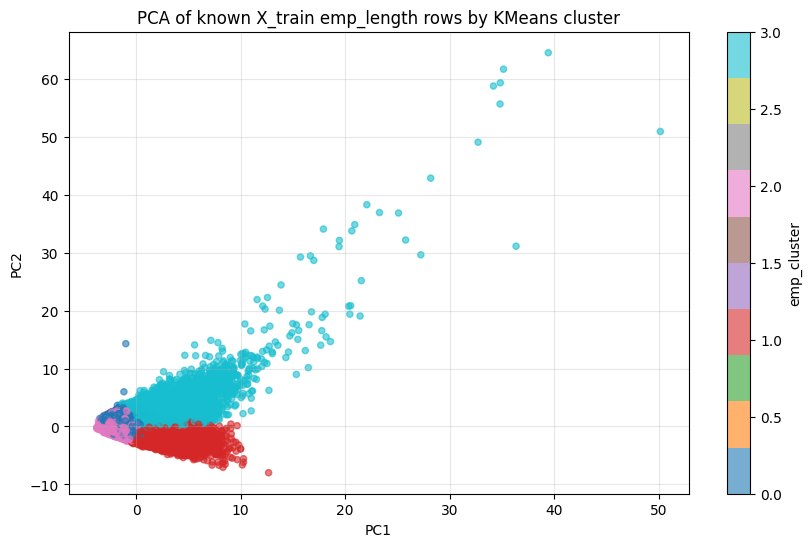

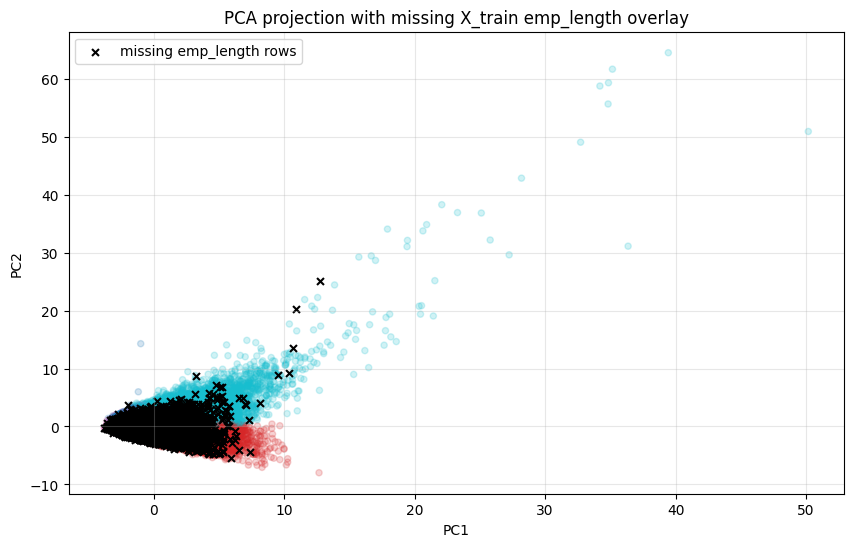

In [138]:
# Visualize the emp_length clustering before the final sanity check
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

elbow_k_values = list(range(1, 11))
elbow_sample_size = min(50000, len(X_known_scaled))
if len(X_known_scaled) > elbow_sample_size:
    elbow_indices = np.random.RandomState(42).choice(len(X_known_scaled), size=elbow_sample_size, replace=False)
    X_elbow_scaled = X_known_scaled[elbow_indices]
else:
    X_elbow_scaled = X_known_scaled

avg_distance_to_centroid = []
for k in elbow_k_values:
    elbow_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    elbow_labels = elbow_kmeans.fit_predict(X_elbow_scaled)
    elbow_distances = np.linalg.norm(X_elbow_scaled - elbow_kmeans.cluster_centers_[elbow_labels], axis=1)
    avg_distance_to_centroid.append(elbow_distances.mean())

emp_length_elbow_summary = pd.DataFrame({
    'k': elbow_k_values,
    'avg_distance_to_centroid': avg_distance_to_centroid,
})
print('Elbow summary:')
print(emp_length_elbow_summary)
print('Elbow sample size:', len(X_elbow_scaled))

plt.figure(figsize=(8, 5))
plt.plot(elbow_k_values, avg_distance_to_centroid, marker='o')
plt.xticks(elbow_k_values)
plt.xlabel('k')
plt.ylabel('Average distance to assigned centroid')
plt.title('Elbow curve for emp_length clustering')
plt.grid(True, alpha=0.3)
plt.show()

train_known_plot = X_train_emp_cluster.loc[known_train.index, cluster_features].copy()
train_known_scaled = scaler.transform(train_known_plot)
pca = PCA(n_components=2, random_state=42)
train_known_coords = pca.fit_transform(train_known_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(train_known_coords[:, 0], train_known_coords[:, 1], c=known_train['emp_cluster'], cmap='tab10', s=20, alpha=0.6)
plt.colorbar(label='emp_cluster')
plt.title('PCA of known X_train emp_length rows by KMeans cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

train_unknown_plot = X_train_emp_cluster[
    X_train_emp_cluster['emp_length'].isna() & X_train_emp_cluster['emp_cluster'].notna()
].copy()

if not train_unknown_plot.empty:
    X_train_unknown = train_unknown_plot[cluster_features].copy()
    train_unknown_scaled = scaler.transform(X_train_unknown)
    train_unknown_coords = pca.transform(train_unknown_scaled)

    plt.figure(figsize=(10, 6))
    plt.scatter(train_known_coords[:, 0], train_known_coords[:, 1], c=known_train['emp_cluster'], cmap='tab10', s=20, alpha=0.2)
    plt.scatter(train_unknown_coords[:, 0], train_unknown_coords[:, 1], c='k', marker='x', s=25, label='missing emp_length rows')
    plt.legend()
    plt.title('PCA projection with missing X_train emp_length overlay')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('No missing X_train emp_length rows with complete clustering features to project.')


In [139]:
#Check the emp_length fill results before applying them downstream
def emp_length_fill_sanity(original_frame, filled_frame, frame_name):
    original_missing_mask = original_frame['emp_length'].isna()
    original_known_mask = original_frame['emp_length'].notna()
    eligible_missing_mask = original_missing_mask & filled_frame['emp_cluster'].notna()
    ineligible_missing_mask = original_missing_mask & filled_frame['emp_cluster'].isna()

    filled_eligible_count = filled_frame.loc[eligible_missing_mask, 'filled_emp_length'].notna().sum()
    unfilled_eligible_count = filled_frame.loc[eligible_missing_mask, 'filled_emp_length'].isna().sum()
    overwritten_known_count = (filled_frame.loc[original_known_mask, 'filled_emp_length'].astype('Int64') != original_frame.loc[original_known_mask, 'emp_length'].astype('Int64')).sum()
    overwritten_known_count = int(overwritten_known_count)

    print(f'\n{frame_name} sanity check')
    print('Original missing emp_length rows:', int(original_missing_mask.sum()))
    print('Eligible missing rows with cluster assignment:', int(eligible_missing_mask.sum()))
    print('Eligible missing rows filled:', int(filled_eligible_count))
    print('Eligible missing rows still unfilled:', int(unfilled_eligible_count))
    print('Missing rows without enough features for clustering:', int(ineligible_missing_mask.sum()))
    print('Known rows overwritten:', overwritten_known_count)

    assert unfilled_eligible_count == 0, f'{frame_name}: some eligible missing rows were not filled'
    assert overwritten_known_count == 0, f'{frame_name}: known emp_length values were overwritten'

    remaining_missing_export = filled_frame.loc[original_missing_mask & filled_frame['filled_emp_length'].isna(), ['id', 'emp_length', 'filled_emp_length', 'emp_cluster', 'emp_length_cluster_estimate', 'emp_length_fill_source']].copy()
    return remaining_missing_export

x_train_emp_length_remaining_missing_after_cluster = emp_length_fill_sanity(X_train, X_train_emp_cluster, 'X_train')
x_test_emp_length_remaining_missing_after_cluster = emp_length_fill_sanity(X_test, X_test_emp_cluster, 'X_test')

emp_length_sanity_store = {
    'x_train_remaining_missing_after_cluster': x_train_emp_length_remaining_missing_after_cluster,
    'x_test_remaining_missing_after_cluster': x_test_emp_length_remaining_missing_after_cluster,
}
print('Remaining missing after cluster:')
print('x_train_remaining_missing_after_cluster', emp_length_sanity_store['x_train_remaining_missing_after_cluster'].shape)
print('x_test_remaining_missing_after_cluster', emp_length_sanity_store['x_test_remaining_missing_after_cluster'].shape)

print('\nemp_length fill sanity checks passed.')



X_train sanity check
Original missing emp_length rows: 26830
Eligible missing rows with cluster assignment: 26818
Eligible missing rows filled: 26818
Eligible missing rows still unfilled: 0
Missing rows without enough features for clustering: 12
Known rows overwritten: 0

X_test sanity check
Original missing emp_length rows: 6674
Eligible missing rows with cluster assignment: 6671
Eligible missing rows filled: 6671
Eligible missing rows still unfilled: 0
Missing rows without enough features for clustering: 3
Known rows overwritten: 0
Remaining missing after cluster:
x_train_remaining_missing_after_cluster (12, 6)
x_test_remaining_missing_after_cluster (3, 6)

emp_length fill sanity checks passed.


In [140]:
#Doing a bit more feature engineering/reduction and encoding 
#Instead of keeping both issue_d and earliest_cr_line we create a new more usefull varaible called credit_maturity at time of application
from datetime import datetime

# Function to calculate months
def credit_maturity_months(issue, earliest):
    issue_date = datetime.strptime(issue, "%b-%Y")
    earliest_date = datetime.strptime(earliest, "%b-%Y")
    months = (issue_date.year - earliest_date.year) * 12 + (issue_date.month - earliest_date.month)
    return int(months)

# Apply function to all rows
X_train["credit_maturity"] = X_train.apply(lambda row: credit_maturity_months(row["issue_d"], row["earliest_cr_line"]), axis=1)
X_test["credit_maturity"] = X_test.apply(lambda row: credit_maturity_months(row["issue_d"], row["earliest_cr_line"]), axis=1)
X_test=X_test.drop(['issue_d','earliest_cr_line'], axis=1)
X_train=X_train.drop(['issue_d','earliest_cr_line'], axis=1)
X_test



,id,loan_amnt,term,int_rate,emp_title,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,credit_maturity
294399,49913257,3500.0,36,12.29,Driver,4,2,35000.0,1,credit_card,FL,16.12,0.0,0.0,NaN,NaN,12.0,0.0,5642.0,49.5,13.0,0.0,NaN,0.0,0.0,18693.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11400.0,NaN,NaN,NaN,6.0,1558.0,60.5,0.0,0.0,14.0,50.0,6.0,6.0,0.0,7.0,NaN,7.0,NaN,0.0,3.0,8.0,5.0,5.0,1.0,11.0,12.0,8.0,12.0,0.0,0.0,0.0,3.0,100.0,40.0,0.0,0.0,27418.0,18693.0,5800.0,16018.0,50
41612,131398943,20000.0,36,14.07,Owner,1,1,100000.0,3,debt_consolidation,CA,22.90,0.0,2.0,NaN,74.0,11.0,1.0,10056.0,44.3,16.0,0.0,NaN,0.0,2403.0,104587.0,2.0,2.0,2.0,3.0,1.0,94531.0,NaN,3.0,6.0,6148.0,44.0,22700.0,1.0,0.0,11.0,9.0,9508.0,45.2,0.0,0.0,47.0,115.0,6.0,1.0,0.0,6.0,NaN,0.0,NaN,0.0,4.0,6.0,7.0,8.0,4.0,9.0,10.0,6.0,11.0,0.0,0.0,0.0,5.0,100.0,14.3,0.0,1.0,119837.0,104587.0,20600.0,97137.0,316
348054,55482837,18000.0,60,18.55,Sr Telecom Analyst,8,1,88691.0,2,credit_card,IL,37.30,2.0,1.0,9.0,61.0,48.0,2.0,40107.0,76.6,75.0,0.0,63.0,0.0,0.0,122655.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52390.0,NaN,NaN,NaN,21.0,2788.0,76.1,0.0,0.0,207.0,100.0,3.0,3.0,1.0,3.0,63.0,1.0,9.0,1.0,10.0,33.0,10.0,16.0,15.0,44.0,59.0,33.0,48.0,0.0,0.0,0.0,3.0,95.4,70.0,2.0,0.0,151179.0,122655.0,11800.0,98789.0,219
507842,67369313,20000.0,36,9.76,RN Nurse,5,1,52000.0,2,debt_consolidation,TX,4.06,0.0,0.0,NaN,NaN,7.0,0.0,3880.0,13.4,8.0,0.0,NaN,0.0,3598.0,3880.0,1.0,0.0,0.0,1.0,20.0,0.0,NaN,1.0,2.0,1911.0,13.0,28900.0,0.0,0.0,0.0,3.0,554.0,17.4,0.0,0.0,20.0,107.0,5.0,5.0,0.0,5.0,NaN,NaN,NaN,0.0,5.0,6.0,5.0,5.0,1.0,7.0,7.0,6.0,7.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,28900.0,3880.0,21100.0,0.0,107
295828,78489153,19000.0,60,9.75,Sales Engineer,10,2,60000.0,1,home_improvement,OH,25.86,1.0,0.0,13.0,NaN,11.0,0.0,2243.0,26.4,30.0,0.0,13.0,0.0,929.0,233362.0,0.0,3.0,0.0,1.0,13.0,45340.0,90.0,0.0,0.0,962.0,78.0,8500.0,2.0,0.0,0.0,1.0,25929.0,68.5,0.0,0.0,139.0,555.0,63.0,13.0,4.0,92.0,29.0,13.0,29.0,5.0,2.0,3.0,3.0,7.0,8.0,7.0,18.0,3.0,11.0,0.0,0.0,1.0,0.0,86.2,50.0,0.0,0.0,277381.0,47583.0,2800.0,72704.0,556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154368,67355568,30000.0,36,11.99,Interior Designer,3,1,85000.0,3,debt_consolidation,CA,12.99,0.0,0.0,NaN,NaN,13.0,0.0,26694.0,76.9,24.0,0.0,NaN,0.0,0.0,30863.0,0.0,6.0,0.0,0.0,26.0,4169.0,19.0,2.0,3.0,14838.0,54.0,34700.0,0.0,0.0,1.0,3.0,2572.0,79.8,0.0,0.0,154.0,155.0,8.0,8.0,0.0,9.0,NaN,9.0,NaN,0.0,3.0,4.0,4.0,7.0,14.0,7.0,10.0,4.0,13.0,0.0,0.0,0.0,2.0,100.0,50.0,0.0,0.0,56700.0,30863.0,21700.0,22000.0,155
446100,41151620,24000.0,60,18.84,stna,8,2,58000.0,3,debt_consolidation,OH,9.00,0.0,0.0,NaN,101.0,16.0,1.0,3655.0,11.6,26.0,0.0,NaN,0.0,0.0,7

In [141]:
#Encoded purpose to one hot 
print(X_train['purpose'].value_counts())

X_train = pd.get_dummies(X_train, columns=['purpose'])
X_test = pd.get_dummies(X_test, columns=['purpose'])

print(X_train.dtypes)

#for val in df['emp_title'].unique():
#   print(val)

#too many to encode anyway -> we have their annual income so emp title may give only marginal improvement on predicting power of the final model. 
#!! otherwise only address is left as object creating new data set in case they become needed

X_train=X_train.drop(['emp_title',], axis=1)
X_test=X_test.drop(['emp_title',], axis=1)
X_train_with_add = X_train
X_test_with_add = X_test
X_train=X_train.drop(['addr_state',], axis=1)
X_test=X_test.drop(['addr_state'], axis=1)
X_test

purpose
debt_consolidation    248115
credit_card            87185
home_improvement       26188
other                  24834
major_purchase          8998
small_business          5706
medical                 4901
car                     4065
moving                  3190
vacation                2866
house                   2316
wedding                  613
renewable_energy         316
educational              106
Name: count, dtype: int64
id                                 object
loan_amnt                         float64
term                                Int64
int_rate                          float64
emp_title                          object
emp_length                          Int64
home_ownership                      int64
annual_inc                        float64
verification_status                 int64
addr_state                         object
dti                               float64
delinq_2yrs                       float64
inq_last_6mths                    float64
mths_since_las

,id,loan_amnt,term,int_rate,emp_length,home_ownership,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,credit_maturity,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
294399,49913257,3500.0,36,12.29,4,2,35000.0,1,16.12,0.0,0.0,NaN,NaN,12.0,0.0,5642.0,49.5,13.0,0.0,NaN,0.0,0.0,18693.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11400.0,NaN,NaN,NaN,6.0,1558.0,60.5,0.0,0.0,14.0,50.0,6.0,6.0,0.0,7.0,NaN,7.0,NaN,0.0,3.0,8.0,5.0,5.0,1.0,11.0,12.0,8.0,12.0,0.0,0.0,0.0,3.0,100.0,40.0,0.0,0.0,27418.0,18693.0,5800.0,16018.0,50,False,True,False,False,False,False,False,False,False,False,False,False,False,False
41612,131398943,20000.0,36,14.07,1,1,100000.0,3,22.90,0.0,2.0,NaN,74.0,11.0,1.0,10056.0,44.3,16.0,0.0,NaN,0.0,2403.0,104587.0,2.0,2.0,2.0,3.0,1.0,94531.0,NaN,3.0,6.0,6148.0,44.0,22700.0,1.0,0.0,11.0,9.0,9508.0,45.2,0.0,0.0,47.0,115.0,6.0,1.0,0.0,6.0,NaN,0.0,NaN,0.0,4.0,6.0,7.0,8.0,4.0,9.0,10.0,6.0,11.0,0.0,0.0,0.0,5.0,100.0,14.3,0.0,1.0,119837.0,104587.0,20600.0,97137.0,316,False,False,True,False,False,False,False,False,False,False,False,False,False,False
348054,55482837,18000.0,60,18.55,8,1,88691.0,2,37.30,2.0,1.0,9.0,61.0,48.0,2.0,40107.0,76.6,75.0,0.0,63.0,0.0,0.0,122655.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52390.0,NaN,NaN,NaN,21.0,2788.0,76.1,0.0,0.0,207.0,100.0,3.0,3.0,1.0,3.0,63.0,1.0,9.0,1.0,10.0,33.0,10.0,16.0,15.0,44.0,59.0,33.0,48.0,0.0,0.0,0.0,3.0,95.4,70.0,2.0,0.0,151179.0,122655.0,11800.0,98789.0,219,False,True,False,False,False,False,False,False,False,False,False,False,False,False
507842,67369313,20000.0,36,9.76,5,1,52000.0,2,4.06,0.0,0.0,NaN,NaN,7.0,0.0,3880.0,13.4,8.0,0.0,NaN,0.0,3598.0,3880.0,1.0,0.0,0.0,1.0,20.0,0.0,NaN,1.0,2.0,1911.0,13.0,28900.0,0.0,0.0,0.0,3.0,554.0,17.4,0.0,0.0,20.0,107.0,5.0,5.0,0.0,5.0,NaN,NaN,NaN,0.0,5.0,6.0,5.0,5.0,1.0,7.0,7.0,6.0,7.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,28900.0,3880.0,21100.0,0.0,107,False,False,True,False,False,False,False,False,False,False,False,False,False,False
295828,78489153,19000.0,60,9.75,10,2,60000.0,1,25.86,1.0,0.0,13.0,NaN,11.0,0.0,2243.0,26.4,30.0,0.0,13.0,0.0,929.0,233362.0,0.0,3.0,0.0,1.0,13.0,45340.0,90.0,0.0,0.0,962.0,78.0,8500.0,2.0,0.0,0.0,1.0,25929.0,68.5,0.0,0.0,139.0,555.0,63.0,13.0,4.0,92.0,29.0,13.0,29.0,5.0,2.0,3.0,3.0,7.0,8.0,7.0,18.0,3.0,11.0,0.0,0.0,1.0,0.0,86.2,50.0,0.0,0.0,277381.0,47583.0,2800.0,72704.0,556,False,False,False,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15436

In [142]:
#everything is encoded
X_train.dtypes

id                                 object
loan_amnt                         float64
term                                Int64
int_rate                          float64
emp_length                          Int64
home_ownership                      int64
annual_inc                        float64
verification_status                 int64
dti                               float64
delinq_2yrs                       float64
inq_last_6mths                    float64
mths_since_last_delinq            float64
mths_since_last_record            float64
open_acc                          float64
pub_rec                           float64
revol_bal                         float64
revol_util                        float64
total_acc                         float64
collections_12_mths_ex_med        float64
mths_since_last_major_derog       float64
acc_now_delinq                    float64
tot_coll_amt                      float64
tot_cur_bal                       float64
open_acc_6m                       

In [143]:
#handling missing values 
#identified problematic columns that have more then 0 missing values
missing_values = X_train.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
print(X_train[['mths_since_last_delinq', 'delinq_2yrs']].head(1000)) # seeing that values that are nan in mths_since_last_delinq are "never" values

# Solving the problem of months since variables
mths_since= [
"mths_since_last_delinq","mths_since_last_record","mths_since_last_major_derog",
"mths_since_rcnt_il","mo_sin_old_il_acct","mo_sin_rcnt_rev_tl_op",
"mo_sin_rcnt_tl","mths_since_recent_bc","mths_since_recent_bc_dlq",
"mths_since_recent_revol_delinq","num_bc_sats",
"num_sats",'all_util','bc_util','percent_bc_gt_75',"revol_util","il_util","tot_cur_bal",'mo_sin_old_rev_tl_op','mths_since_recent_inq',
"pct_tl_nvr_dlq","tot_hi_cred_lim","total_bc_limit","num_tl_120dpd_2m"
]
#Creating a seperate dataset for tree models
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()



for col in mths_since: 
    X_train[col + "_is_nan"] = X_train[col].isna()#.astype(int)
    X_train[col] = X_train[col].fillna(0)
    X_test[col + "_is_nan"] = X_test[col].isna()#.astype(int)
    X_test[col] = X_test[col].fillna(0)



safe_tofill = [
"open_acc_6m","open_rv_12m","open_rv_24m","total_bal_il","max_bal_bc","inq_fi","inq_last_12m","total_cu_tl",
"acc_open_past_24mths","mort_acc","num_accts_ever_120_pd","num_actv_bc_tl","num_actv_rev_tl","num_bc_tl","num_il_tl","num_op_rev_tl","open_il_12m","open_act_il","open_il_24m",
"num_rev_tl_bal_gt_0","num_tl_30dpd","num_tl_90g_dpd_24m","num_tl_op_past_12m","total_bal_ex_mort","total_il_high_credit_limit","total_rev_hi_lim",
"tot_coll_amt","num_rev_accts",
]



for col in safe_tofill:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)


median_val = X_train["avg_cur_bal"].median()
median_val2 = X_test["avg_cur_bal"].median()

# Fill NaNs in both datasets using the their medians # Not having a credit account open doesn't mean you are a really good borrower that pays everything up before interest date. People who dont have account shouldn't get perfect score by default.
X_train["avg_cur_bal"] = X_train["avg_cur_bal"].fillna(median_val)
X_test["avg_cur_bal"] = X_test["avg_cur_bal"].fillna(median_val2)



#X_test.head(10)

missing_values = X_train.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
print(X_train_tree.head())
print(X_train_tree.shape)
print(X_train.shape)


emp_length                         26830
mths_since_last_delinq            208410
mths_since_last_record            344394
revol_util                           240
collections_12_mths_ex_med            12
mths_since_last_major_derog       304475
tot_coll_amt                       19444
tot_cur_bal                        19444
open_acc_6m                       249284
open_act_il                       249284
open_il_12m                       249284
open_il_24m                       249284
mths_since_rcnt_il                254052
total_bal_il                      249284
il_util                           271306
open_rv_12m                       249284
open_rv_24m                       249284
max_bal_bc                        249284
all_util                          249293
total_rev_hi_lim                   19444
inq_fi                            249284
total_cu_tl                       249284
inq_last_12m                      249284
acc_open_past_24mths               13384
avg_cur_bal     

In [144]:
X_train.head()

,id,loan_amnt,term,int_rate,emp_length,home_ownership,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,credit_maturity,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,mths_since_last_delinq_is_nan,mths_since_last_record_is_nan,mths_since_last_major_derog_is_nan,mths_since_rcnt_il_is_nan,mo_sin_old_il_acct_is_nan,mo_sin_rcnt_rev_tl_op_is_nan,mo_sin_rcnt_tl_is_nan,mths_since_recent_bc_is_nan,mths_since_recent_bc_dlq_is_nan,mths_since_recent_revol_delinq_is_nan,num_bc_sats_is_nan,num_sats_is_nan,all_util_is_nan,bc_util_is_nan,percent_bc_gt_75_is_nan,revol_util_is_nan,il_util_is_nan,tot_cur_bal_is_nan,mo_sin_old_rev_tl_op_is_nan,mths_since_recent_inq_is_nan,pct_tl_nvr_dlq_is_nan,tot_hi_cred_lim_is_nan,total_bc_limit_is_nan,num_tl_120dpd_2m_is_nan
392193,38598337,20000.0,60,14.99,6,2,80000.0,3,25.16,4.0,0.0,16.0,0.0,5.0,0.0,7241.0,69.0,20.0,0.0,0.0,0.0,0.0,61461.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10500.0,0.0,0.0,0.0,2.0,15365.0,0.0,0.0,0.0,87.0,320.0,8.0,8.0,1.0,76.0,16.0,1.0,16.0,0.0,0.0,1.0,1.0,9.0,5.0,3.0,14.0,1.0,5.0,0.0,0.0,0.0,1.0,80.0,0.0,0.0,0.0,82630.0,61461.0,0.0,72130.0,320,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,True,True,True,False,True,False,False,False,False,False,False,False
199618,65109298,5400.0,36,16.55,3,1,45000.0,2,13.87,0.0,1.0,0.0,0.0,8.0,0.0,5463.0,51.5,8.0,0.0,0.0,0.0,0.0,15557.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10600.0,0.0,0.0,0.0,6.0,1945.0,77.2,0.0,0.0,21.0,40.0,7.0,7.0,0.0,7.0,0.0,5.0,0.0,0.0,2.0,4.0,2.0,2.0,1.0,7.0,7.0,5.0,8.0,0.0,0.0,0.0,5.0,100.0,50.0,0.0,0.0,25263.0,15557.0,5800.0,14663.0,40,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,False,False,False,False,True,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False
440877,42733391,12950.0,36,12.69,10,1,44000.0,3,10.47,0.0,0.0,0.0,60.0,20.0,1.0,8814.0,40.2,64.0,0.0,0.0,0.0,0.0,8814.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21900.0,0.0,0.0,0.0,12.0,518.0,57.1,0.0,0.0,145.0,338.0,12.0,6.0,5.0,12.0,0.0,8.0,0.0,0.0,6.0,11.0,8.0,22.0,11.0,20.0,48.0,11.0,18.0,0.0,0.0,0.0,3.0,100.0,57.1,1.0,0.0,21900.0,8814.0,10700.0,0.0,338,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,True,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False
449111,46611319,14900.0,36,16.99,10,1,34000.0,2,17.72,0.0,0.0,0.0,0.0,7.0,0.0,10091.0,39.1,10.0,0.0,0.0,0.0,0.0,17899.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25800.0,0.0,0.0,0.0,4.0,2557.0,47.7,0.0,0.0,44.0,173.0,11.0,5.0,0.0,11.0,0.0,0.0,0.0,0.0,4.0,5.0,5.0,7.0,2.0,6.0,8.0,5.0,7.0,0.0,0.0,0.0,2.0,

In [145]:
#Transforming Emp_length to categorical to differentiate <1 years from Not working and Owning a business (unknown)
#
#Can be dine wuth median as well
#
#
#
#
#

emp_length_train_df = emp_length_fill_store['train_fill_export'][['id', 'filled_emp_length']].copy()
emp_length_test_df = emp_length_fill_store['test_fill_export'][['id', 'filled_emp_length']].copy()
print(emp_length_train_df)

emp_length_train_map = emp_length_train_df.assign(id=emp_length_train_df['id'].astype(str)).drop_duplicates(subset=['id']).set_index('id')['filled_emp_length']
emp_length_test_map = emp_length_test_df.assign(id=emp_length_test_df['id'].astype(str)).drop_duplicates(subset=['id']).set_index('id')['filled_emp_length']

for frame_name, frame, fill_map in [
    ('X_train', X_train, emp_length_train_map),
    ('X_test', X_test, emp_length_test_map),
    ('X_train_tree', X_train_tree, emp_length_train_map),
    ('X_test_tree', X_test_tree, emp_length_test_map),
]:
    frame['id'] = frame['id'].astype(str)
    frame['filled_emp_length'] = frame['id'].map(fill_map).astype('Int64')
    frame['emp_length'] = frame['filled_emp_length'].combine_first(frame['emp_length']).astype('Int64')
    print(frame_name, 'remaining emp_length missing:', int(frame['emp_length'].isna().sum()))
    frame.drop(columns=['filled_emp_length'], inplace=True)

emp_length_fallback = X_train['emp_length'].dropna().median()
print('emp_length fallback value:', emp_length_fallback)

for frame_name, frame in [
    ('X_train', X_train),
    ('X_test', X_test),
    ('X_train_tree', X_train_tree),
    ('X_test_tree', X_test_tree),
]:
    frame['emp_length_was_missing_after_cluster'] = frame['emp_length'].isna()
    frame['emp_length'] = frame['emp_length'].fillna(emp_length_fallback).astype('Int64')
    print(frame_name, 'emp_length missing after fallback:', int(frame['emp_length'].isna().sum()))



'''
X_train["emp_length_cat"] = pd.cut(
    X_train["emp_length"],
    bins=[0,2,4,6,8,10],
    labels=["1","2","3","4","5"]
)

X_test["emp_length_cat"] = pd.cut(
    X_test["emp_length"],
    bins=[0,2,4,6,8,10],
    labels=["1","2","3","4","5"]
)

X_train["emp_length_cat"] = X_train["emp_length_cat"].cat.add_categories("unknown").fillna("unknown")
X_test["emp_length_cat"] = X_test["emp_length_cat"].cat.add_categories("unknown").fillna("unknown")
'''


              id  filled_emp_length
392193  38598337                  6
199618  65109298                  3
440877  42733391                 10
449111  46611319                 10
391434  69613130                 10
...          ...                ...
371403  58281191                  4
491263  43166639                  1
470924  39679736                  1
491755   3381473                  6
128037    997521                 10

[419399 rows x 2 columns]
X_train remaining emp_length missing: 12
X_test remaining emp_length missing: 3
X_train_tree remaining emp_length missing: 12
X_test_tree remaining emp_length missing: 3
emp_length fallback value: 6.0
X_train emp_length missing after fallback: 0
X_test emp_length missing after fallback: 0
X_train_tree emp_length missing after fallback: 0
X_test_tree emp_length missing after fallback: 0


'\nX_train["emp_length_cat"] = pd.cut(\n    X_train["emp_length"],\n    bins=[0,2,4,6,8,10],\n    labels=["1","2","3","4","5"]\n)\n\nX_test["emp_length_cat"] = pd.cut(\n    X_test["emp_length"],\n    bins=[0,2,4,6,8,10],\n    labels=["1","2","3","4","5"]\n)\n\nX_train["emp_length_cat"] = X_train["emp_length_cat"].cat.add_categories("unknown").fillna("unknown")\nX_test["emp_length_cat"] = X_test["emp_length_cat"].cat.add_categories("unknown").fillna("unknown")\n'

In [146]:
#confirming data are all acceptable types. Cat?*
#
#
#
#
#
'''
X_train = X_train.drop(columns="emp_length")
X_test = X_test.drop(columns="emp_length")
X_test.head(10)
X_test.dtypes
'''

'\nX_train = X_train.drop(columns="emp_length")\nX_test = X_test.drop(columns="emp_length")\nX_test.head(10)\nX_test.dtypes\n'

In [147]:
#lets check misssing values

missing_values = X_test.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
#checking that the rest of the missing values are mostly unavailable datapoints or errors. As there are small in comparison with dataset size we just delete them.
for v in X_test['pub_rec_bankruptcies']:
    print(v)

cols = [
    'collections_12_mths_ex_med',
    'chargeoff_within_12_mths',
    'pub_rec_bankruptcies',
    'tax_liens'
]
print(X_train.shape)

X_test_tree = X_test_tree.dropna(subset=cols)
X_train_tree = X_train_tree.dropna(subset=cols)
X_test = X_test.dropna(subset=cols)
X_train = X_train.dropna(subset=cols)
Y_train = Y_train.loc[X_train.index]
Y_test = Y_test.loc[X_test.index]

print(X_train_tree.shape)
print(Y_train.shape)


collections_12_mths_ex_med    10
chargeoff_within_12_mths      10
pub_rec_bankruptcies          59
tax_liens                      8
dtype: int64
0.0
0.0
2.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
1.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
3.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0

In [148]:
#checking final missing value counts and dataset size.
missing_values = X_train.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
#Great, Zero Missing Values
X_train_tree.shape

X_train_tree.dtypes


Series([], dtype: int64)


id                                       object
loan_amnt                               float64
term                                      Int64
int_rate                                float64
emp_length                                Int64
home_ownership                            int64
annual_inc                              float64
verification_status                       int64
dti                                     float64
delinq_2yrs                             float64
inq_last_6mths                          float64
mths_since_last_delinq                  float64
mths_since_last_record                  float64
open_acc                                float64
pub_rec                                 float64
revol_bal                               float64
revol_util                              float64
total_acc                               float64
collections_12_mths_ex_med              float64
mths_since_last_major_derog             float64
acc_now_delinq                          

In [149]:
print(X_train.dtypes)

id                                        object
loan_amnt                                float64
term                                       Int64
int_rate                                 float64
emp_length                                 Int64
home_ownership                             int64
annual_inc                               float64
verification_status                        int64
dti                                      float64
delinq_2yrs                              float64
inq_last_6mths                           float64
mths_since_last_delinq                   float64
mths_since_last_record                   float64
open_acc                                 float64
pub_rec                                  float64
revol_bal                                float64
revol_util                               float64
total_acc                                float64
collections_12_mths_ex_med               float64
mths_since_last_major_derog              float64
acc_now_delinq      

In [150]:
#Checking multicoliniarity on numeric variables
print(X_train.select_dtypes(include=['int64', 'float64',]).shape)
print(X_train_tree.select_dtypes(include=['int64', 'float64',]).shape)
import plotly.express as px

#Printing X_train Dataset
numeric_df = X_train.select_dtypes(include=['int64', 'float64',])

corr_matrix = numeric_df.corr(method='spearman')


fig = px.imshow(
    corr_matrix, 
    text_auto=False, 
    aspect="auto", 
    color_continuous_scale='RdBu_r', 
    zmin=-1, zmax=1
)
fig.update_layout(width=1000, height=1000)
fig.show()


#Printing X_train_tree Dataset (without missing values impeted and _is_nan vars created)

numeric_df = X_train_tree.select_dtypes(include=['int64', 'float64',])

corr_matrix = numeric_df.corr(method='spearman')


fig = px.imshow(
    corr_matrix, 
    text_auto=False, 
    aspect="auto", 
    color_continuous_scale='RdBu_r', 
    zmin=-1, zmax=1
)
fig.update_layout(width=1000, height=1000)
fig.show()

#we can see an artificial multicoliniarity due to imputation so we added the tree model datasets...


(419204, 74)
(419204, 74)


In [151]:
import numpy as np
print(X_train_tree.shape)

numeric_df = X_train.select_dtypes(include=['int64', 'float64',])

corr_matrix = numeric_df.corr(method='pearson')


fig = px.imshow(
    corr_matrix, 
    text_auto=False, 
    aspect="auto", 
    color_continuous_scale='RdBu_r', 
    zmin=-1, zmax=1
)
fig.update_layout(width=1000, height=1000)
fig.show()





numeric_df = X_train_tree.select_dtypes(include=['int64', 'float64',])

corr_matrix = numeric_df.corr(method='pearson')


fig = px.imshow(
    corr_matrix, 
    text_auto=False, 
    aspect="auto", 
    color_continuous_scale='RdBu_r', 
    zmin=-1, zmax=1
)
fig.update_layout(width=1000, height=1000)
fig.show()
X_train_tree




#check if cleaning forward selection and not cleaned are different  
#check if filling nulls give drustically different correlations this might be because of the fact that we created flag for mo_since but correlation ignores them thus there can be mo_since correlation with other variables
#FUTURE ME: Which were truthful

Y_train_encoded = Y_train.map({
    "Fully Paid": 0,
    "Charged Off": 1
})

Y_test_encoded = Y_test.map({
    "Fully Paid": 0,
    "Charged Off": 1
})

#removing highly correlated features based on better logic.
threshold = 0.75 
corr_matrix = X_train_tree.corr().abs()

# Get the upper triangle (k=1) to avoid duplicates and self-correlation
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Print pairs exceeding the threshold
for col in upper.columns:
    for row in upper.index[upper[col] < -threshold ]:
        print(f"{row} & {col}: {upper.loc[row, col]:.2f}")

print(X_train_tree.shape)

#after logical decisions the below variables are getting removed. Criteria on removal included better intrerpretability and miniming problematic variables which corelate with many futures
high_multiColl = [
"num_sats","open_il_12m","open_rv_24m",
"total_rev_hi_lim","avg_cur_bal","bc_util",
"mths_since_recent_bc_dlq","mths_since_recent_revol_delinq","num_actv_bc_tl",
"num_op_rev_tl","num_rev_accts","num_rev_tl_bal_gt_0","acc_now_delinq","num_tl_op_past_12m","percent_bc_gt_75","tot_hi_cred_lim","total_bal_ex_mort","total_bc_limit",
"total_il_high_credit_limit","mo_sin_old_rev_tl_op"
]

X_train_tree = X_train_tree.drop(columns=high_multiColl)
X_test_tree = X_test_tree.drop(columns = high_multiColl)

print(X_train_tree.shape)


#Looking at matrix after removal of highly correlated variables. Improvements noticed
numeric_df = X_train_tree.select_dtypes(include=['int64', 'float64',])

corr_matrix = numeric_df.corr(method='pearson')


fig = px.imshow(
    corr_matrix, 
    text_auto=False, 
    aspect="auto", 
    color_continuous_scale='RdBu_r', 
    zmin=-1, zmax=1
)
fig.update_layout(width=1000, height=1000)
fig.show()

X_train_tree



(419204, 90)


(419204, 90)
(419204, 70)


,id,loan_amnt,term,int_rate,emp_length,home_ownership,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,max_bal_bc,all_util,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,pct_tl_nvr_dlq,pub_rec_bankruptcies,tax_liens,credit_maturity,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,emp_length_was_missing_after_cluster
392193,38598337,20000.0,60,14.99,6,2,80000.0,3,25.16,4.0,0.0,16.0,NaN,5.0,0.0,7241.0,69.0,20.0,0.0,NaN,0.0,61461.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,87.0,8.0,8.0,1.0,76.0,1.0,0.0,1.0,1.0,9.0,5.0,0.0,0.0,0.0,80.0,0.0,0.0,320,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
199618,65109298,5400.0,36,16.55,3,1,45000.0,2,13.87,0.0,1.0,NaN,NaN,8.0,0.0,5463.0,51.5,8.0,0.0,NaN,0.0,15557.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,0.0,0.0,21.0,7.0,7.0,0.0,7.0,5.0,0.0,4.0,2.0,2.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,40,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
440877,42733391,12950.0,36,12.69,10,1,44000.0,3,10.47,0.0,0.0,NaN,60.0,20.0,1.0,8814.0,40.2,64.0,0.0,NaN,0.0,8814.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0,0.0,145.0,12.0,6.0,5.0,12.0,8.0,0.0,11.0,8.0,22.0,11.0,0.0,0.0,0.0,100.0,1.0,0.0,338,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
449111,46611319,14900.0,36,16.99,10,1,34000.0,2,17.72,0.0,0.0,NaN,NaN,7.0,0.0,10091.0,39.1,10.0,0.0,NaN,0.0,17899.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,0.0,0.0,44.0,11.0,5.0,0.0,11.0,NaN,0.0,5.0,5.0,7.0,2.0,0.0,0.0,0.0,100.0,0.0,0.0,173,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
391434,69613130,12000.0,36,15.77,10,2,110000.0,3,16.03,6.0,1.0,1.0,NaN,14.0,0.0,32528.0,84.5,31.0,0.0,13.0,0.0,152113.0,3.0,2.0,2.0,5.0,22538.0,86.0,2.0,1951.0,85.0,0.0,0.0,1.0,6.0,0.0,0.0,123.0,3.0,3.0,5.0,14.0,3.0,0.0,9.0,3.0,7.0,6.0,0.0,1.0,2.0,64.5,0.0,0.0,378,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371403,58281191,24000.0,60,10.99,4,1,65000.0,3,15.65,1.0,0.0,14.0,NaN,18.0,0.0,30582.0,33.8,44.0,1.0,14.0,0.0,41275.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,0.0,0.0,133.0,3.0,3.0,0.0,3.0,11.0,1.0,8.0,11.0,19.0,4.0,0.0,0.0,1.0,97.7,0.0,0.0,146,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
491263,43166639,1200.0,36,14.65,1,3,18000.0,3,29.13,1.0,2.0,11.0,NaN,14.0,0.0,1029.0,27.1,24.0,0.0,NaN,0.0,40680.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.0,0.0,66.0,14.0,11.0,0.0,14.0,0.0,0.0,3.0,2.0,2.0,20.0,0.0,0.0,0.0,95.7,0.0,0.0,66,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
470924,39679736,17350.0,36,19.99,1,2,58000.0,1,21.37,1.0,1.0,23.0,NaN,12.0,0.0,27988.0,79.3,21.0,0.0,NaN,0.0,138546.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.0,0.0,246.0,1.0,1.0,2.0,1.0,4.0,0.0,7.0,7.0,11.0,4.0,0.0,0.0

In [152]:
#Removing high VIF futures left after corr filtering in X_train_tree
cols_to_drop = []

# Separate continuous from binary/bool
continuous_cols = [col for col in X_train_tree.columns if X_train_tree[col].nunique() > 2]
df_vif = X_train_tree[continuous_cols].copy()

while True:
    corr_matrix = df_vif.corr()
    corr_inv = np.linalg.pinv(corr_matrix.values)
    vif = pd.Series(np.diag(corr_inv), index=df_vif.columns).sort_values(ascending=False)
    
    if vif.iloc[0] < 5:
        break
    
    worst = vif.index[0]
    cols_to_drop.append(worst)
    df_vif = df_vif.drop(columns=worst)
    print(f"Dropped: {worst} — VIF={vif.iloc[0]:.2f}")

# Apply drops to the original dataframe
X_train_tree = X_train_tree.drop(columns=cols_to_drop)
X_test_tree = X_test_tree.drop(columns = cols_to_drop)
print(f"\nAll dropped: {cols_to_drop}")

Dropped: pub_rec — VIF=26.10
Dropped: total_acc — VIF=18.33
Dropped: open_acc — VIF=6.94
Dropped: all_util — VIF=6.36

All dropped: ['pub_rec', 'total_acc', 'open_acc', 'all_util']


In [153]:
#Final check at X_train_tree corr_matrix

numeric_df = X_train_tree.select_dtypes(include=['int64', 'float64',])

corr_matrix = numeric_df.corr(method='pearson')


fig = px.imshow(
    corr_matrix, 
    text_auto=False, 
    aspect="auto", 
    color_continuous_scale='RdBu_r', 
    zmin=-1, zmax=1
)
fig.update_layout(width=1000, height=1000)
fig.show()
X_train_tree


,id,loan_amnt,term,int_rate,emp_length,home_ownership,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,revol_bal,revol_util,collections_12_mths_ex_med,mths_since_last_major_derog,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,max_bal_bc,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,pct_tl_nvr_dlq,pub_rec_bankruptcies,tax_liens,credit_maturity,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,emp_length_was_missing_after_cluster
392193,38598337,20000.0,60,14.99,6,2,80000.0,3,25.16,4.0,0.0,16.0,NaN,7241.0,69.0,0.0,NaN,0.0,61461.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,87.0,8.0,8.0,1.0,76.0,1.0,0.0,1.0,1.0,9.0,5.0,0.0,0.0,0.0,80.0,0.0,0.0,320,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
199618,65109298,5400.0,36,16.55,3,1,45000.0,2,13.87,0.0,1.0,NaN,NaN,5463.0,51.5,0.0,NaN,0.0,15557.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,0.0,0.0,21.0,7.0,7.0,0.0,7.0,5.0,0.0,4.0,2.0,2.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,40,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
440877,42733391,12950.0,36,12.69,10,1,44000.0,3,10.47,0.0,0.0,NaN,60.0,8814.0,40.2,0.0,NaN,0.0,8814.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0,0.0,145.0,12.0,6.0,5.0,12.0,8.0,0.0,11.0,8.0,22.0,11.0,0.0,0.0,0.0,100.0,1.0,0.0,338,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
449111,46611319,14900.0,36,16.99,10,1,34000.0,2,17.72,0.0,0.0,NaN,NaN,10091.0,39.1,0.0,NaN,0.0,17899.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,0.0,0.0,44.0,11.0,5.0,0.0,11.0,NaN,0.0,5.0,5.0,7.0,2.0,0.0,0.0,0.0,100.0,0.0,0.0,173,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
391434,69613130,12000.0,36,15.77,10,2,110000.0,3,16.03,6.0,1.0,1.0,NaN,32528.0,84.5,0.0,13.0,0.0,152113.0,3.0,2.0,2.0,5.0,22538.0,86.0,2.0,1951.0,0.0,0.0,1.0,6.0,0.0,0.0,123.0,3.0,3.0,5.0,14.0,3.0,0.0,9.0,3.0,7.0,6.0,0.0,1.0,2.0,64.5,0.0,0.0,378,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371403,58281191,24000.0,60,10.99,4,1,65000.0,3,15.65,1.0,0.0,14.0,NaN,30582.0,33.8,1.0,14.0,0.0,41275.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,0.0,0.0,133.0,3.0,3.0,0.0,3.0,11.0,1.0,8.0,11.0,19.0,4.0,0.0,0.0,1.0,97.7,0.0,0.0,146,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
491263,43166639,1200.0,36,14.65,1,3,18000.0,3,29.13,1.0,2.0,11.0,NaN,1029.0,27.1,0.0,NaN,0.0,40680.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.0,0.0,66.0,14.0,11.0,0.0,14.0,0.0,0.0,3.0,2.0,2.0,20.0,0.0,0.0,0.0,95.7,0.0,0.0,66,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
470924,39679736,17350.0,36,19.99,1,2,58000.0,1,21.37,1.0,1.0,23.0,NaN,27988.0,79.3,0.0,NaN,0.0,138546.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.0,0.0,246.0,1.0,1.0,2.0,1.0,4.0,0.0,7.0,7.0,11.0,4.0,0.0,0.0,0.0,90.5,0.0,0.0,272,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
491755,3381473,9300.0,36,6.62,6,2,97144.0,1,18.16,0.0,3.0,NaN,NaN,10403.0,29.7,0.0

In [154]:
#now filling the missing values of X_train_tree with no multicoliniarity!
missing_values = X_train_tree.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

X_train_tree.shape
high_multiColl += ["pub_rec", "total_acc", "open_acc", "all_util"]



for col in mths_since: #fill with 999 and use tree models only! 
    if col in high_multiColl:
        continue
    X_train_tree[col] = X_train[col].fillna(999)
    X_test_tree[col] = X_test[col].fillna(999)


for col in safe_tofill:
    if col in high_multiColl:
        continue
    X_test_tree[col] = X_test_tree[col].fillna(0)
    X_train_tree[col] = X_train_tree[col].fillna(0)



missing_values = X_train_tree.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
print(X_train_tree.shape)
print(Y_train_encoded.shape)




mths_since_last_delinq         208410
mths_since_last_record         344394
revol_util                        240
mths_since_last_major_derog    304280
tot_coll_amt                    19249
tot_cur_bal                     19249
open_acc_6m                    249089
open_act_il                    249089
open_il_24m                    249089
mths_since_rcnt_il             253857
total_bal_il                   249089
il_util                        271111
open_rv_12m                    249089
max_bal_bc                     249089
inq_fi                         249089
total_cu_tl                    249089
inq_last_12m                   249089
acc_open_past_24mths            13189
mo_sin_old_il_acct              31367
mo_sin_rcnt_rev_tl_op           19250
mo_sin_rcnt_tl                  19249
mort_acc                        13189
mths_since_recent_bc            17175
mths_since_recent_inq           48904
num_accts_ever_120_pd           19249
num_actv_rev_tl                 19249
num_bc_sats 

In [155]:
missing_values = X_test_tree.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

print(X_train_tree.shape)
print(Y_train.shape)
print(Y_train_encoded.shape)
print(X_train.shape)

Series([], dtype: int64)
(419204, 66)
(419204,)
(419204,)
(419204, 114)


In [156]:
# Do the same VIF and Corr filtering for the other set as well
threshold = 0.75  # Set your limit
corr_matrix = X_train.corr().abs()


upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
#Here as artificial colliniarity is suspected to be induced no logical check-to-remove is done. remove the one of the multicollinar variables
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

# Print which ones will be removed
print("Columns dropped due to high correlation:")
for col in to_drop:
    print(f"{col}")

# Drop these columns from the dataset
X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)


Columns dropped due to high correlation:
open_il_24m
open_rv_24m
all_util
total_rev_hi_lim
avg_cur_bal
bc_util
mths_since_recent_revol_delinq
num_actv_rev_tl
num_bc_sats
num_op_rev_tl
num_rev_accts
num_rev_tl_bal_gt_0
num_sats
num_tl_30dpd
num_tl_op_past_12m
percent_bc_gt_75
pub_rec_bankruptcies
tot_hi_cred_lim
total_il_high_credit_limit
credit_maturity
mths_since_last_record_is_nan
mths_since_last_major_derog_is_nan
mths_since_rcnt_il_is_nan
mo_sin_rcnt_rev_tl_op_is_nan
mo_sin_rcnt_tl_is_nan
mths_since_recent_bc_dlq_is_nan
mths_since_recent_revol_delinq_is_nan
num_bc_sats_is_nan
num_sats_is_nan
all_util_is_nan
bc_util_is_nan
percent_bc_gt_75_is_nan
il_util_is_nan
tot_cur_bal_is_nan
mo_sin_old_rev_tl_op_is_nan
pct_tl_nvr_dlq_is_nan
tot_hi_cred_lim_is_nan
total_bc_limit_is_nan


In [157]:
#VIF for X_train

cols_to_drop.clear()
continuous_cols = [col for col in X_train.columns if X_train[col].nunique() > 2]
df_vif = X_train[continuous_cols].copy()

while True:
    corr_matrix = df_vif.corr()
    corr_inv = np.linalg.pinv(corr_matrix.values)
    vif = pd.Series(np.diag(corr_inv), index=df_vif.columns).sort_values(ascending=False)
    
    if vif.iloc[0] < 5:
        break
    
    worst = vif.index[0]
    cols_to_drop.append(worst)
    df_vif = df_vif.drop(columns=worst)
    print(f"Dropped: {worst} — VIF={vif.iloc[0]:.2f}")

# Apply drops to the original full dataframe
X_train = X_train.drop(columns=cols_to_drop)
X_test= X_test.drop(columns = cols_to_drop)
print(f"\nAll dropped: {cols_to_drop}")

#Last view at final X_train corr_matrix

numeric_df = X_train.select_dtypes(include=['int64', 'float64',])

corr_matrix = numeric_df.corr(method='pearson')


fig = px.imshow(
    corr_matrix, 
    text_auto=False, 
    aspect="auto", 
    color_continuous_scale='RdBu_r', 
    zmin=-1, zmax=1
)
fig.update_layout(width=1000, height=1000)
fig.show()


Dropped: total_acc — VIF=10.32

All dropped: ['total_acc']


Feature ranking:
1. dti (0.036195)
2. term (0.032744)
3. revol_util (0.031810)
4. annual_inc (0.030241)
5. credit_maturity (0.029550)
6. revol_bal (0.028530)
7. acc_open_past_24mths (0.028363)
8. tot_cur_bal (0.028068)
9. mths_since_recent_bc (0.026800)
10. num_actv_rev_tl (0.026685)
11. mo_sin_old_il_acct (0.026435)
12. mths_since_recent_inq (0.026433)
13. emp_length (0.026175)
14. num_bc_tl (0.025641)
15. num_bc_sats (0.025433)
16. num_il_tl (0.025428)
17. mo_sin_rcnt_tl (0.025330)
18. mo_sin_rcnt_rev_tl_op (0.025157)
19. mort_acc (0.022614)
20. mths_since_last_delinq (0.021934)


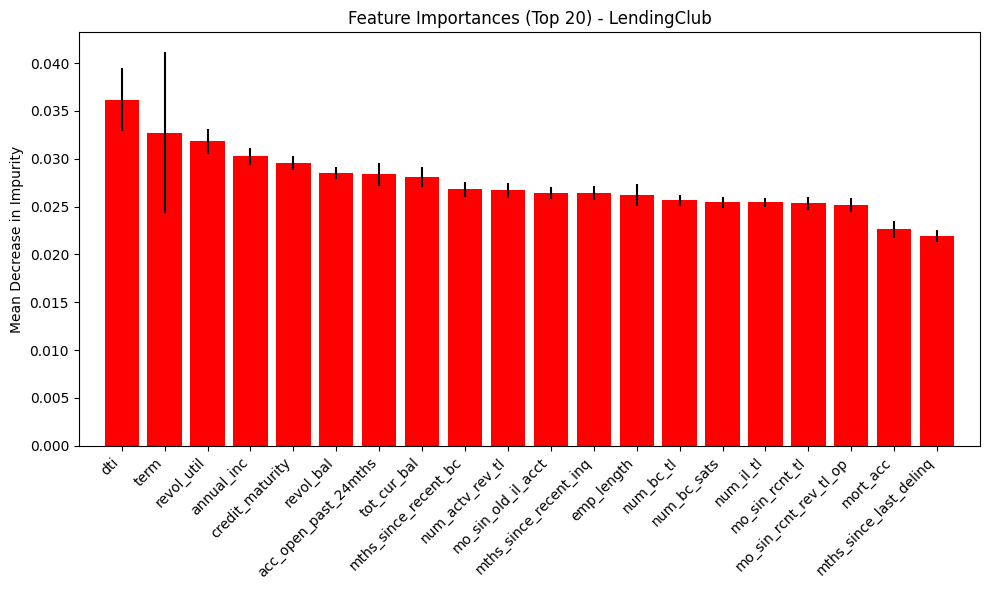

In [158]:
from sklearn.ensemble import ExtraTreesClassifier

feature_names = X_train_tree.columns

estimator = ExtraTreesClassifier(n_estimators=100, max_features='sqrt', random_state=0)
estimator.fit(X_train_tree, Y_train)

importances = estimator.feature_importances_
std = np.std([tree.feature_importances_ for tree in estimator.estimators_], axis=0)

indices = np.argsort(importances)[::-1]

excluded = {"int_rate", "id", "loan_amnt"}
filtered_indices = [i for i in indices if feature_names[i] not in excluded]

top_n = 20
indices_top = filtered_indices[:top_n]

print("Feature ranking:")
for f, feature_idx in enumerate(indices_top, start=1):
    print(f"{f}. {feature_names[feature_idx]} ({importances[feature_idx]:.6f})")

plt.figure(figsize=(10, 6))
plt.title(f"Feature Importances (Top {top_n}) - LendingClub")

plt.bar(
    range(top_n),
    importances[indices_top],
    color="r",
    yerr=std[indices_top],
    align="center"
)

plt.xticks(range(top_n), feature_names[indices_top], rotation=45, ha='right')
plt.xlim([-1, top_n])
plt.ylabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()


In [159]:
#Future extraction with X_train_tree dataset

from sklearn.feature_selection import RFECV
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, f1_score

custom_profit = make_scorer(f1_score)

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    device='cuda',          
    tree_method='hist'      
)

rfecv = RFECV(
    estimator=xgb,
    cv=5,
    scoring='f1',
    min_features_to_select=5,
    n_jobs=-1
)

X_train_tree_fs = X_train_tree.drop(columns=["id", "loan_amnt", "int_rate"])

rfecv.fit(X_train_tree_fs, Y_train_encoded)
print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 50


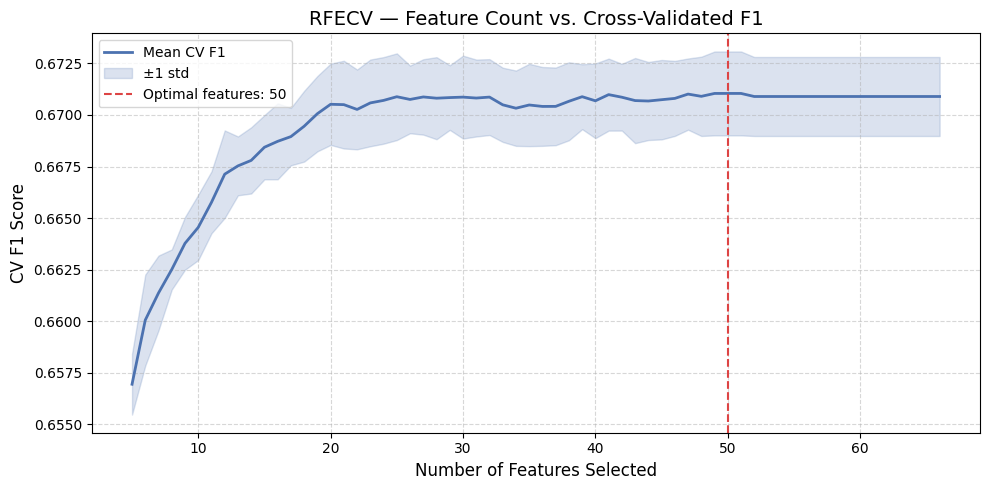

In [160]:
import matplotlib.pyplot as plt
import numpy as np

mean_scores = rfecv.cv_results_["mean_test_score"]
std_scores  = rfecv.cv_results_["std_test_score"]
n_features  = np.arange(rfecv.min_features_to_select,
                         rfecv.min_features_to_select + len(mean_scores))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_features, mean_scores, color="#4C72B0", linewidth=2, label="Mean CV F1")
ax.fill_between(n_features,
                mean_scores - std_scores,
                mean_scores + std_scores,
                alpha=0.2, color="#4C72B0", label="±1 std")

ax.axvline(rfecv.n_features_, color="#DD4444", linestyle="--", linewidth=1.5,
           label=f"Optimal features: {rfecv.n_features_}")

ax.set_xlabel("Number of Features Selected", fontsize=12)
ax.set_ylabel("CV F1 Score", fontsize=12)
ax.set_title("RFECV — Feature Count vs. Cross-Validated F1", fontsize=14)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("rfecv_curve.png", dpi=150)
plt.show()



In [161]:

# Find the best score and apply the 1-SE rule
mean_scores = rfecv.cv_results_["mean_test_score"]
std_scores  = rfecv.cv_results_["std_test_score"]

best_idx  = mean_scores.argmax()
threshold = mean_scores[best_idx] - std_scores[best_idx]

# Pick the fewest features that still clears the threshold
optimal_n = rfecv.min_features_to_select + np.argmax(mean_scores >= threshold)

print("RFECV optimal features :", rfecv.n_features_)
print("Conservative cutoff (1-SE):", optimal_n)


print("\n--- Debug Variables ---")
print("Best index (feature count with highest F1):", best_idx)
print("Best mean F1 score                        :", round(mean_scores[best_idx], 4))
print("Std at best index                         :", round(std_scores[best_idx], 4))
print("Threshold (best - 1 std)                  :", round(threshold, 4))


feature_names  = X_train_tree_fs.columns
selected_names = feature_names[rfecv.support_]          # filters to 49
importances    = rfecv.estimator_.feature_importances_  # 49 values

top_22 = (pd.Series(importances, index=selected_names)
            .sort_values(ascending=False)
            .head(optimal_n))                           # ← cuts to 22

print(top_22)

RFECV optimal features : 50
Conservative cutoff (1-SE): 18

--- Debug Variables ---
Best index (feature count with highest F1): 45
Best mean F1 score                        : 0.671
Std at best index                         : 0.002
Threshold (best - 1 std)                  : 0.669
int_rate                       0.386155
term                           0.088175
verification_status            0.052550
home_ownership                 0.040392
mort_acc                       0.033781
acc_open_past_24mths           0.032789
id                             0.032382
dti                            0.025486
tot_cur_bal                    0.024660
num_actv_rev_tl                0.022401
inq_last_6mths                 0.019513
annual_inc                     0.017675
loan_amnt                      0.013885
mths_since_recent_bc           0.013700
purpose_small_business         0.012168
delinq_2yrs                    0.011950
mths_since_last_major_derog    0.011803
revol_bal                      0.011428

In [162]:
from sklearn.feature_selection import RFECV
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, f1_score

custom_profit = make_scorer(f1_score)

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    device='cuda',          
    tree_method='hist'      
)

rfecv = RFECV(
    estimator=xgb,
    cv=5,
    scoring='f1',
    min_features_to_select=5,
    n_jobs=-1
)

X_train_fs = X_train.drop(columns=["id", "loan_amnt", "int_rate"])

rfecv.fit(X_train_fs, Y_train_encoded)
print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 50


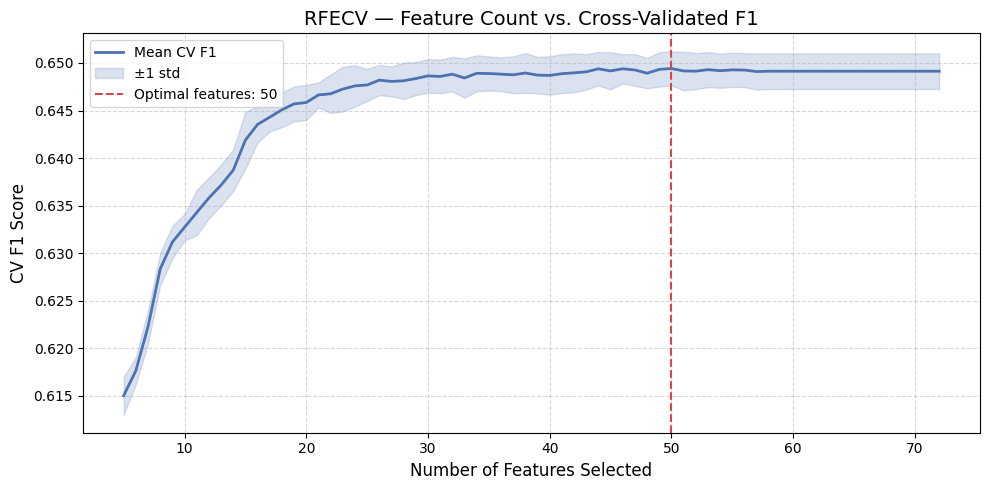

RFECV optimal features : 50
Conservative cutoff (1-SE): 25

--- Debug Variables ---
Best index (feature count with highest F1): 45
Best mean F1 score                        : 0.6494
Std at best index                         : 0.0018
Threshold (best - 1 std)                  : 0.6476


In [163]:
import matplotlib.pyplot as plt
import numpy as np

mean_scores = rfecv.cv_results_["mean_test_score"]
std_scores  = rfecv.cv_results_["std_test_score"]
n_features  = np.arange(rfecv.min_features_to_select,
                         rfecv.min_features_to_select + len(mean_scores))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_features, mean_scores, color="#4C72B0", linewidth=2, label="Mean CV F1")
ax.fill_between(n_features,
                mean_scores - std_scores,
                mean_scores + std_scores,
                alpha=0.2, color="#4C72B0", label="±1 std")

ax.axvline(rfecv.n_features_, color="#DD4444", linestyle="--", linewidth=1.5,
           label=f"Optimal features: {rfecv.n_features_}")

ax.set_xlabel("Number of Features Selected", fontsize=12)
ax.set_ylabel("CV F1 Score", fontsize=12)
ax.set_title("RFECV — Feature Count vs. Cross-Validated F1", fontsize=14)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("rfecv_curve.png", dpi=150)
plt.show()



# Find the best score and apply the 1-SE rule
mean_scores = rfecv.cv_results_["mean_test_score"]
std_scores  = rfecv.cv_results_["std_test_score"]

best_idx  = mean_scores.argmax()
threshold = mean_scores[best_idx] - std_scores[best_idx]

# Pick the fewest features that still clears the threshold
optimal_n = rfecv.min_features_to_select + np.argmax(mean_scores >= threshold)

print("RFECV optimal features :", rfecv.n_features_)
print("Conservative cutoff (1-SE):", optimal_n)


print("\n--- Debug Variables ---")
print("Best index (feature count with highest F1):", best_idx)
print("Best mean F1 score                        :", round(mean_scores[best_idx], 4))
print("Std at best index                         :", round(std_scores[best_idx], 4))
print("Threshold (best - 1 std)                  :", round(threshold, 4))

In [164]:
# Find the best score and apply the 1-SE rule
mean_scores = rfecv.cv_results_["mean_test_score"]
std_scores  = rfecv.cv_results_["std_test_score"]

best_idx  = mean_scores.argmax()
threshold = mean_scores[best_idx] - std_scores[best_idx]

# Pick the fewest features that still clears the threshold
optimal_n = rfecv.min_features_to_select + np.argmax(mean_scores >= threshold)

print("RFECV optimal features :", rfecv.n_features_)
print("Conservative cutoff (1-SE):", optimal_n)


print("\n--- Debug Variables ---")
print("Best index (feature count with highest F1):", best_idx)
print("Best mean F1 score                        :", round(mean_scores[best_idx], 4))
print("Std at best index                         :", round(std_scores[best_idx], 4))
print("Threshold (best - 1 std)                  :", round(threshold, 4))

feature_names  = X_train_fs.columns
print("All X_train features:")
print(feature_names.tolist())

print("\nemp_length position in X_train:")
print(feature_names.get_loc("emp_length") if "emp_length" in feature_names else "emp_length not present")

selected_names = feature_names[rfecv.support_]          # filters to 49
importances    = rfecv.estimator_.feature_importances_  # 49 values

top_22 = (pd.Series(importances, index=selected_names)
            .sort_values(ascending=False)
            .head(optimal_n))                           # ← cuts to 22

print(top_22)
#all_selected = pd.Series(importances, index=selected_names).sort_values(ascending=False)
#print(all_selected)


RFECV optimal features : 50
Conservative cutoff (1-SE): 25

--- Debug Variables ---
Best index (feature count with highest F1): 45
Best mean F1 score                        : 0.6494
Std at best index                         : 0.0018
Threshold (best - 1 std)                  : 0.6476
All X_train features:
['term', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'max_bal_bc', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_si

In [165]:
import pandas as pd
import warnings
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier                          # ← NEW
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, make_scorer)

warnings.filterwarnings('ignore')
#Creating The right scorer to address all the tricky pitfalls
def profit_score(y_true, y_pred, amounts, rates, cost_of_capital=0.0):
    """
    Economic Value Added (EVA) Metric.
    
    Measures how much MORE the bank made compared to simply parking
    all capital at the risk-free rate.
    
    Formula:
        EVA = (interest_earned - principal_lost) - (total_capital * cost_of_capital)
    
    Properties:
        - Reject all  → EVA = 0         (no value added, no value destroyed)
        - Approve all → EVA can be very negative (defaults punish hard)
        - Good model  → EVA > 0         (genuine lending skill rewarded)
    """
    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    amounts = np.array(amounts)
    rates   = np.array(rates)

    approved = (y_pred == 0)

    paid_back = (y_true == 0) & approved
    defaulted = (y_true == 1) & approved

    # What we earned from good loans
    interest_earned = (amounts[paid_back] * (rates[paid_back] / 100)).sum()

    # What we lost from bad loans (94% recovery loss)
    principal_lost = (amounts[defaulted] * 0.94).sum()

    # The baseline: what we could have earned risk-free on ALL capital
    total_capital = amounts[approved].sum()
    opportunity_cost = total_capital * cost_of_capital

    # Excess profit over doing nothing
    eva = (interest_earned - principal_lost) - opportunity_cost

    return eva


f1_scorer = make_scorer(f1_score, average='binary')

# ── 2. Feature Subset (from selection results) ────────────────────
selected_cols = [
    "term",
    "verification_status",
    "acc_open_past_24mths",
    "inq_last_12m",
    "home_ownership",
    "open_rv_12m",
    "inq_last_6mths",
    "tot_cur_bal",
    "dti",
    "mort_acc",
    "annual_inc",
    "total_bc_limit",
    "purpose_credit_card",
    "max_bal_bc",
    "revol_util",
    "delinq_2yrs",
    "purpose_small_business",
    "num_actv_bc_tl",
    "mths_since_recent_bc",
    "mths_since_recent_inq_is_nan",
    "mths_since_last_delinq_is_nan",
    "num_tl_120dpd_2m_is_nan",
    "mths_since_recent_inq",
    "mo_sin_old_il_acct",
    "mo_sin_old_rev_tl_op",
    "id",
    "loan_amnt",
    "int_rate",
]

X_train = X_train[selected_cols].copy()
X_test  = X_test[selected_cols].copy()
X_train_sub = X_train.drop(columns=["id", "loan_amnt", "int_rate"])#removing for modeling
X_test_sub = X_test.drop(columns=["id", "loan_amnt", "int_rate"])#removing for modeling

# Map Y_test labels to numeric
mapping      = {'Fully Paid': 0, 'Charged Off': 1}
Y_test_proc  = Y_test.map(mapping)


# ── 3. Classifiers (SVC → CatBoost) ──────────────────────────────
classifiers = {
    "LGBMClassifier"        : LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1, device="gpu"),
    "XGBClassifier"         : XGBClassifier(random_state=42, n_jobs=-1, verbosity=0, tree_method="hist", device="cuda"),
    "CatBoostClassifier"    : CatBoostClassifier(random_state=42, verbose=0, task_type="GPU"),  
    #"LogisticRegression"    : LogisticRegression(max_iter=1000, random_state=42),
    #"KNeighborsClassifier"  : KNeighborsClassifier(),
    #"GaussianNB"            : GaussianNB(),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42, n_jobs=-1),
    #"AdaBoostClassifier"    : AdaBoostClassifier(random_state=42),
}


# ── 4. Train & Evaluate ────────────────────────────────────────────
cv      = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

print(f"Starting training on selected subset ({len(selected_cols)} features)...")

for name, clf in classifiers.items():
    try:
        # Cross-validation scored by F1 (primary metric)
        cv_f1 = cross_val_score(
            clf, X_train_sub, Y_train_encoded,
            cv=cv, scoring=f1_scorer, n_jobs=1
        ).mean()

        # Fit on full training data
        clf.fit(X_train_sub, Y_train_encoded)

        # Predict on test data
        y_pred = clf.predict(X_test_sub)

        eva = profit_score(
            y_true  = Y_test_proc,
            y_pred  = y_pred,
            amounts = X_test["loan_amnt"].values,  # CHANGED: actual loan amounts
            rates   = X_test["int_rate"].values     # CHANGED: actual interest rates
        )

        results.append({
            "Model"       : name,
            "CV F1"       : round(cv_f1, 4),                                               # ← primary sort key
            "Test F1"     : round(f1_score(Y_test_proc, y_pred, average='binary'), 4),
            "EVA ($)"  : round(eva, 0),            
            "Accuracy"    : round(accuracy_score(Y_test_proc, y_pred), 4),
            "Precision"   : round(precision_score(Y_test_proc, y_pred), 4),
            "Recall"      : round(recall_score(Y_test_proc, y_pred), 4),
        })
        print(f"  ✓ {name} Done")

    except Exception as e:
        print(f"  ✕ Error training {name}: {e}")


# ── 5. Final Results (sorted by CV F1) ────────────────────────────
results_df = (pd.DataFrame(results)
                .sort_values("CV F1", ascending=False)
                .reset_index(drop=True))

print("\n--- Selected Subset Performance Results ---")
print(results_df.to_string(index=False))


#make the test 0.8/0.2'''

Starting training on selected subset (28 features)...
  ✓ LGBMClassifier Done
  ✓ XGBClassifier Done
  ✓ CatBoostClassifier Done
  ✓ DecisionTreeClassifier Done
  ✓ RandomForestClassifier Done

--- Selected Subset Performance Results ---
                 Model  CV F1  Test F1      EVA ($)  Accuracy  Precision  Recall
        LGBMClassifier 0.6542   0.6557 -194482925.0    0.6520     0.6497  0.6618
    CatBoostClassifier 0.6530   0.6566 -196547132.0    0.6548     0.6541  0.6592
         XGBClassifier 0.6509   0.6516 -200803002.0    0.6496     0.6487  0.6544
RandomForestClassifier 0.6389   0.6414 -210621424.0    0.6430     0.6453  0.6376
DecisionTreeClassifier 0.5617   0.5582 -284793193.0    0.5593     0.5604  0.5561


In [166]:
import pandas as pd
import numpy as np
import warnings
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier                           # ← NEW
from sklearn.model_selection import StratifiedKFold, cross_val_score
# ↓ NEW: Imported fbeta_score
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, fbeta_score, make_scorer) 

warnings.filterwarnings('ignore')
#Creating The right scorer to address all the tricky pitfalls
def profit_score(y_true, y_pred, amounts, rates, cost_of_capital=0.0):
    """
    Economic Value Added (EVA) Metric.
    
    Measures how much MORE the bank made compared to simply parking
    all capital at the risk-free rate.
    
    Formula:
        EVA = (interest_earned - principal_lost) - (total_capital * cost_of_capital)
    
    Properties:
        - Reject all  → EVA = 0         (no value added, no value destroyed)
        - Approve all → EVA can be very negative (defaults punish hard)
        - Good model  → EVA > 0         (genuine lending skill rewarded)
    """
    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    amounts = np.array(amounts)
    rates   = np.array(rates)

    approved = (y_pred == 0)

    paid_back = (y_true == 0) & approved
    defaulted = (y_true == 1) & approved

    # What we earned from good loans
    interest_earned = (amounts[paid_back] * (rates[paid_back] / 100)).sum()

    # What we lost from bad loans (94% recovery loss)
    principal_lost = (amounts[defaulted] * 0.94).sum()

    # The baseline: what we could have earned risk-free on ALL capital
    total_capital = amounts[approved].sum()
    opportunity_cost = total_capital * cost_of_capital

    # Excess profit over doing nothing
    eva = (interest_earned - principal_lost) - opportunity_cost

    return eva

# ↓ NEW: Changed to fbeta_score with beta=3
f3_scorer = make_scorer(fbeta_score, beta=3, average='binary') 

# ── 2. Feature Subset (from selection results) ────────────────────
selected_cols = [
    "term",
    "verification_status",
    "acc_open_past_24mths",
    "inq_last_12m",
    "home_ownership",
    "open_rv_12m",
    "inq_last_6mths",
    "tot_cur_bal",
    "dti",
    "mort_acc",
    "annual_inc",
    "total_bc_limit",
    "purpose_credit_card",
    "max_bal_bc",
    "revol_util",
    "delinq_2yrs",
    "purpose_small_business",
    "num_actv_bc_tl",
    "mths_since_recent_bc",
    "mths_since_recent_inq_is_nan",
    "mths_since_last_delinq_is_nan",
    "num_tl_120dpd_2m_is_nan",
    "mths_since_recent_inq",
    "mo_sin_old_il_acct",
    "mo_sin_old_rev_tl_op",
    "id",
    "loan_amnt",
    "int_rate",
]

X_train = X_train[selected_cols].copy()
X_test  = X_test[selected_cols].copy()
X_train_sub = X_train.drop(columns=["id", "loan_amnt", "int_rate"])#removing for modeling
X_test_sub = X_test.drop(columns=["id", "loan_amnt", "int_rate"])#removing for modeling

# Map Y_test labels to numeric
mapping      = {'Fully Paid': 0, 'Charged Off': 1}
Y_test_proc  = Y_test.map(mapping)


# ── 3. Classifiers (SVC → CatBoost) ──────────────────────────────
classifiers = {
    "LGBMClassifier"        : LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1, device="gpu"),
    "XGBClassifier"         : XGBClassifier(random_state=42, n_jobs=-1, verbosity=0, tree_method="hist", device="cuda"),
    "CatBoostClassifier"    : CatBoostClassifier(random_state=42, verbose=0, task_type="GPU"),  
    #"LogisticRegression"    : LogisticRegression(max_iter=1000, random_state=42),
    #"KNeighborsClassifier"  : KNeighborsClassifier(),
    #"GaussianNB"            : GaussianNB(),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42, n_jobs=-1),
    #"AdaBoostClassifier"    : AdaBoostClassifier(random_state=42),
}


# ── 4. Train & Evaluate ────────────────────────────────────────────
cv      = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

print(f"Starting training on selected subset ({len(selected_cols)} features)...")

for name, clf in classifiers.items():
    try:
        # ↓ NEW: Cross-validation scored by F3
        cv_f3 = cross_val_score(
            clf, X_train_sub, Y_train_encoded,
            cv=cv, scoring=f3_scorer, n_jobs=1
        ).mean()

        # Fit on full training data
        clf.fit(X_train_sub, Y_train_encoded)

        # Predict on test data
        y_pred = clf.predict(X_test_sub)

        eva = profit_score(
            y_true  = Y_test_proc,
            y_pred  = y_pred,
            amounts = X_test["loan_amnt"].values,  # CHANGED: actual loan amounts
            rates   = X_test["int_rate"].values     # CHANGED: actual interest rates
        )

        results.append({
            "Model"       : name,
            "CV F3"       : round(cv_f3, 4),                                               # ← primary sort key
            "Test F3"     : round(fbeta_score(Y_test_proc, y_pred, beta=3, average='binary'), 4), # ← NEW: beta=3
            "EVA ($)"     : round(eva, 0),            
            "Accuracy"    : round(accuracy_score(Y_test_proc, y_pred), 4),
            "Precision"   : round(precision_score(Y_test_proc, y_pred), 4),
            "Recall"      : round(recall_score(Y_test_proc, y_pred), 4),
        })
        print(f"  ✓ {name} Done")

    except Exception as e:
        print(f"  ✕ Error training {name}: {e}")


# ── 5. Final Results (sorted by CV F3) ────────────────────────────
results_df = (pd.DataFrame(results)
                .sort_values("CV F3", ascending=False) # ← NEW: Sorted by CV F3
                .reset_index(drop=True))

print("\n--- Selected Subset Performance Results ---")
print(results_df.to_string(index=False))

Starting training on selected subset (28 features)...
  ✓ LGBMClassifier Done
  ✓ XGBClassifier Done
  ✓ CatBoostClassifier Done
  ✓ DecisionTreeClassifier Done


KeyboardInterrupt: 

In [ ]:
from sklearn.utils import resample

# Separate X based on Y labels
X_good = X_train[Y_train_encoded == 0]
X_bad  = X_train[Y_train_encoded == 1]

# Keep all good, undersample bad to 1/4
n_good = len(X_good)
n_bad  = int(n_good / 4)

# Undersample bad
X_bad_resampled = resample(X_bad, n_samples=n_bad, random_state=42, replace=False)

# Combine X
X_train_imbalanced = pd.concat([X_good, X_bad_resampled])

# Build Y directly from known labels — no resampling needed
y_train_imbalanced = pd.Series(
    [0] * n_good + [1] * n_bad,
    index=X_train_imbalanced.index  # keep index aligned
)

# Shuffle both together
X_train_imbalanced = X_train_imbalanced.sample(frac=1, random_state=42)
Y_train_imbalanced = y_train_imbalanced.loc[X_train_imbalanced.index]
X_train_imbalanced

,term,verification_status,acc_open_past_24mths,home_ownership,inq_last_12m,inq_last_6mths,mort_acc,dti,tot_cur_bal,open_rv_12m,annual_inc,purpose_credit_card,total_bc_limit,max_bal_bc,delinq_2yrs,mths_since_recent_inq_is_nan,revol_util,purpose_small_business,num_actv_bc_tl,mths_since_recent_bc,mths_since_last_major_derog,tot_coll_amt,id,loan_amnt,int_rate,emp_length
173258,36,1,2.0,3,0.0,1.0,1.0,7.48,14659.0,0.0,60000.0,False,30600.0,0.0,0.0,False,34.1,False,4.0,18.0,0.0,0.0,9848316,14000.0,7.62,10
289407,36,3,16.0,2,5.0,0.0,4.0,6.98,157498.0,10.0,52400.0,False,12500.0,642.0,1.0,False,14.0,False,3.0,6.0,19.0,7869.0,79612977,4500.0,14.46,10
442169,36,3,3.0,1,0.0,1.0,5.0,16.17,131722.0,0.0,55000.0,False,2000.0,0.0,6.0,False,37.1,False,1.0,96.0,37.0,0.0,11266161,5000.0,14.47,10
322049,36,2,5.0,2,0.0,0.0,3.0,21.89,124964.0,0.0,75000.0,False,21800.0,0.0,0.0,False,60.4,False,4.0,34.0,0.0,0.0,23262898,34475.0,11.67,8
23658,36,3,5.0,2,0.0,1.0,6.0,25.55,422382.0,0.0,130000.0,False,128000.0,0.0,0.0,False,28.7,False,9.0,162.0,0.0,0.0,8998318,21000.0,7.62,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241140,36,2,7.0,1,3.0,2.0,3.0,33.70,34358.0,4.0,39956.8,False,10100.0,1871.0,0.0,False,41.5,False,4.0,2.0,0.0,0.0,85787199,9575.0,25.69,10
354150,60,3,3.0,2,0.0,0.0,2.0,21.55,250413.0,0.0,66500.0,False,500.0,0.0,0.0,False,85.5,False,1.0,48.0,0.0,0.0,39532080,12000.0,12.99,10
55089,60,1,8.0,2,6.0,1.0,1.0,17.26,102876.0,6.0,71700.0,False,40300.0,6385.0,0.0,False,25.4,False,4.0,3.0,38.0,0.0,105956161,12600.0,14.99,10
417510,60,1,8.0,1,0.0,0.0,0.0,30.42,54260.0,0.0,46342.0,False,46600.0,0.0,1.0,True,22.4,False,3.0,4.0,21.0,0.0,58100148,18000.0,12.29,3


In [ ]:
X_good_test = X_test[Y_test_encoded == 0]
X_bad_test  = X_test[Y_test_encoded == 1]

n_good_test = len(X_good_test)
n_bad_test  = int(n_good_test / 4)

X_bad_test_resampled = resample(X_bad_test, n_samples=n_bad_test, random_state=42, replace=False)

X_test_imbalanced = pd.concat([X_good_test, X_bad_test_resampled])
y_test_imbalanced = pd.Series(
    [0] * n_good_test + [1] * n_bad_test,
    index=X_test_imbalanced.index
)

X_test_imbalanced = X_test_imbalanced.sample(frac=1, random_state=42)
Y_test_imbalanced = y_test_imbalanced.loc[X_test_imbalanced.index]


In [ ]:
#tuning

import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import fbeta_score, make_scorer

# ---------------------------------------------------------------
# 1. SCORER — F-beta β=3 heavily weights recall (catching bad borrowers)
# ---------------------------------------------------------------
fbeta3_scorer = make_scorer(fbeta_score, beta=3, pos_label=1)

# ---------------------------------------------------------------
# 2. MODEL — class_weight handles imbalance during training loss
# ---------------------------------------------------------------
lgbm = lgb.LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    device='gpu',        # ✅ use GPU
    gpu_platform_id=0,   # ✅ first GPU (change if you have multiple)
)

# ---------------------------------------------------------------
# 3. PARAM GRID — most impactful LightGBM params, first pass
# ---------------------------------------------------------------
param_grid = {
    'n_estimators':      [50, 75, 100],
    'num_leaves':        [15, 20, 25, 31],
    'learning_rate':     [0.005, 0.01, 0.02],
    'min_child_samples': [5, 10, 15, 20],
}

# ---------------------------------------------------------------
# 4. CROSS VALIDATION — stratified to preserve imbalance ratio in each fold
# ---------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------------------------------------
# 5. GRIDSEARCH — tuned on imbalanced data (real-world distribution)
# ---------------------------------------------------------------
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring=fbeta3_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True  # retrains best model on full X_train_imbalanced after search
    
)

X_train_imbalanced_model = X_train.drop(columns=["id", "loan_amnt", "int_rate"])

grid_search.fit(X_train_imbalanced_model, Y_train_encoded)
# ---------------------------------------------------------------
# 6. RESULTS
# ---------------------------------------------------------------
print("Best F-beta (β=3) score:", round(grid_search.best_score_, 4))
print("Best params:\n", grid_search.best_params_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best F-beta (β=3) score: 0.6309
Best params:
 {'learning_rate': 0.02, 'min_child_samples': 5, 'n_estimators': 100, 'num_leaves': 31}


In [ ]:
X_test_model = X_test_imbalanced.drop(columns=["id", "loan_amnt", "int_rate"])

y_proba = best_model.predict_proba(X_test_model)[:, 1]
y_pred  = (y_proba >= 0.36).astype(int)

test_amounts = X_test_imbalanced["loan_amnt"].values
test_rates   = X_test_imbalanced["int_rate"].values

eva = profit_score(Y_test_imbalanced, y_pred, test_amounts, test_rates,0.0)
f1  = fbeta_score(Y_test_imbalanced, y_pred, beta=3)

print(f"EVA:          ${eva:,.2f}")
print(f"F-beta (β=2): {round(f1, 4)}")

EVA:          $4,143,144.68
F-beta (β=2): 0.7197


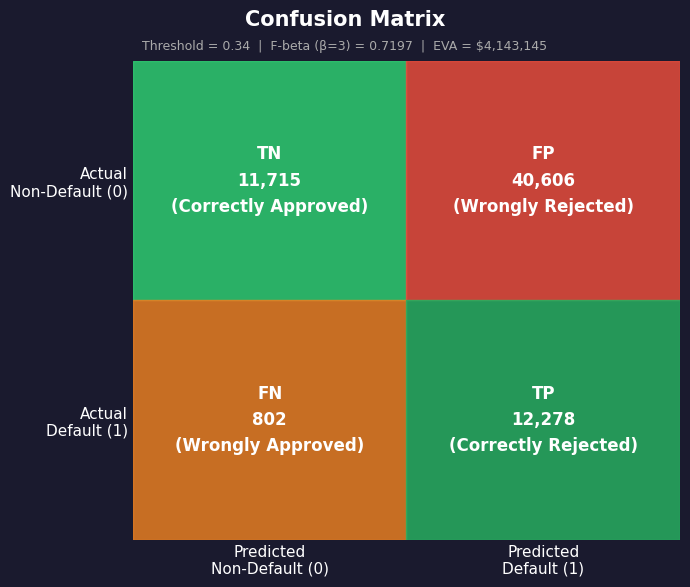

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Confusion Matrix Data ---
cm = confusion_matrix(Y_test_imbalanced, y_pred)
tn, fp, fn, tp = cm.ravel()

labels = np.array([
    [f"TN\n{tn:,}\n(Correctly Approved)",  f"FP\n{fp:,}\n(Wrongly Rejected)"],
    [f"FN\n{fn:,}\n(Wrongly Approved)",    f"TP\n{tp:,}\n(Correctly Rejected)"]
])

# Color map: good predictions = green tones, bad = red tones
colors = np.array([
    ["#2ecc71", "#e74c3c"],
    ["#e67e22", "#27ae60"]
])

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1 - i), 1, 1,
                                    color=colors[i][j], alpha=0.85, zorder=1))
        ax.text(j + 0.5, 1 - i + 0.5, labels[i][j],
                ha="center", va="center", fontsize=12,
                fontweight="bold", color="white", zorder=2,
                linespacing=1.6)

# Axis formatting
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(["Predicted\nNon-Default (0)", "Predicted\nDefault (1)"],
                    fontsize=11, color="white")
ax.set_yticklabels(["Actual\nDefault (1)", "Actual\nNon-Default (0)"],
                    fontsize=11, color="white")
ax.tick_params(colors="white", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Title & subtitle
fig.text(0.5, 0.97, "Confusion Matrix", ha="center", va="top",
         fontsize=15, fontweight="bold", color="white")
fig.text(0.5, 0.92, f"Threshold = 0.34  |  F-beta (β=3) = {round(f1, 4)}  |  EVA = ${eva:,.0f}",
         ha="center", va="top", fontsize=9, color="#aaaaaa")

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

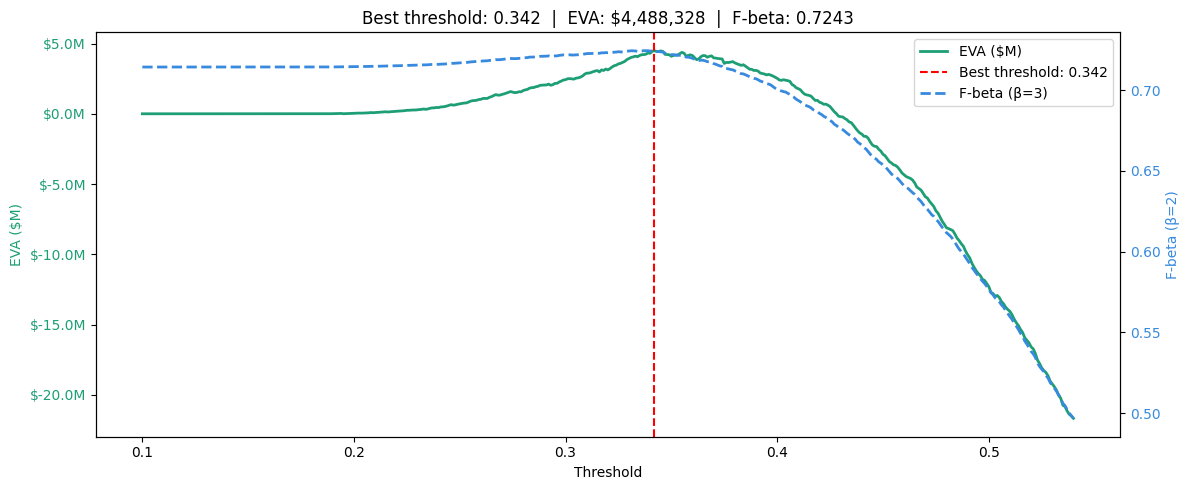


Best threshold : 0.342
EVA at cutoff  : $4,488,328.15
F-beta at cutoff: 0.7243


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.1, 0.54, 0.001)

evas, fbetas = [], []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    evas.append(profit_score(Y_test_imbalanced, y_pred_t, test_amounts, test_rates))
    fbetas.append(fbeta_score(Y_test_imbalanced, y_pred_t, beta=3, zero_division=0))

evas   = np.array(evas)
fbetas = np.array(fbetas)

best_idx = np.argmax(evas)
best_t   = thresholds[best_idx]
best_eva = evas[best_idx]
best_f   = fbetas[best_idx]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(thresholds, evas / 1e6, color="#1D9E75", linewidth=2, label="EVA ($M)")
ax1.axvline(best_t, color="red", linestyle="--", linewidth=1.5, label=f"Best threshold: {best_t:.3f}")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("EVA ($M)", color="#1D9E75")
ax1.tick_params(axis="y", labelcolor="#1D9E75")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))

ax2 = ax1.twinx()
ax2.plot(thresholds, fbetas, color="#378ADD", linewidth=2, linestyle="--", label="F-beta (β=3)")
ax2.set_ylabel("F-beta (β=2)", color="#378ADD")
ax2.tick_params(axis="y", labelcolor="#378ADD")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(f"Best threshold: {best_t:.3f}  |  EVA: ${best_eva:,.0f}  |  F-beta: {best_f:.4f}")
plt.tight_layout()
plt.show()

print(f"\nBest threshold : {best_t:.3f}")
print(f"EVA at cutoff  : ${best_eva:,.2f}")
print(f"F-beta at cutoff: {best_f:.4f}")

In [ ]:
#X test and discuss